## Python packages required for the analyses

In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.interpolate import make_interp_spline
from matplotlib.gridspec import GridSpec
from scipy import stats  # Used for linear regression and statistics
# Imports the python-docx library and its components
from docx import Document  # pip install python-docx
from docx.shared import Inches, Pt  # Units of measurement for figures and text
from docx.enum.text import WD_ALIGN_PARAGRAPH  # Paragraph alignment
import os
# Imports low-level XML elements to insert custom fields
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from matplotlib.lines import Line2D

# Automatic Calculation of the Local Meteoric Line (LMWL)

This script calculates the Local Meteoric Line (LMWL) from isotopic rainfall data, using the δ¹⁸O and δ²H (deuterium) isotopes. The LMWL is generated using ordinary least squares (OLS) regression, as well as orthogonal (RMA) and precipitation-weighted (PWLSR) regression.

The main steps include:
- Reading and processing the input file (.xlsx)
- Date conversion and data filtering
- Calculation of OLSR, RMA, and PWLSR regressions
- Plotting results with histograms and trend linesndência


In [2]:
# Definição dos caminhos das pastas
input_folder = './stations_data'  # Pasta onde estão os arquivos Excel de entrada
output_folder = 'station_outputs'  # Pasta onde os resultados serão salvos
os.makedirs(output_folder, exist_ok=True)  # Cria a pasta de saída, se não existir

# Lista de colunas obrigatórias nos arquivos de entrada
required_columns = ['precipitacao', 'O18', 'H2', 'temperature', 'umidade']
# required_columns = ['O18', 'H2']

# Lista para armazenar nomes de arquivos com colunas ausentes
missing_columns_report = []

# Lista onde será armazenado o resumo estatístico de cada estação
summary_lines = []

### Reduced Principal Axis Regression (RMA) for Isotope Ratio Analysis

This code snippet implements a custom function to perform **Reduced Principal Axis Regression (RMA)**, also known as **Orthogonal Regression**. This type of regression is especially useful in scientific analyses where **both variables have uncertainties or measurement errors**—as is typically the case in environmental isotope studies (δ¹⁸O and δ²H).

Unlike Ordinary Least Squares (OLS) regression, which minimizes only the residuals in the vertical (Y) direction, RMA **minimizes the distances perpendicular to the points** relative to the fitted line. This makes it more suitable for evaluating symmetric or natural relationships between variables.

The function `rma_regression(x, y)` takes two vectors (e.g., δ¹⁸O and δ²H) and retu- **Slope and intercept of the RMA line**
- **Standard error** associated with the intercept
- **t-values** and **p-values** (for statistical significance testing)
- **Degrees of freedom** of the regression
- **OLS p-value** (returned together, as it serves as the basis for calculating the RMA)

The use of this function is recommended for:

- Construction of LMWLs (Local Meteoric Water Lines)
- Comparisons with the GMWL (Global Meteoric Water Line)
- Climatological analyses based on isotopic signatures
- Hydrological studies with multiple sensors, stations, or instrumental uncertainties

This procedure enhances the robustness of the analyses, providing a more reliable statistical approach when OLS may introduce bias in physical-climatic interpretations.ticas.

In [3]:
# Função para realizar a regressão ortogonal (RMA)
def rma_regression(x, y):
    """
    Executa a Regressão de Eixo Principal Reduzido (RMA) entre duas variáveis.
    Retorna valores estatísticos como inclinação, intercepto, erros, t-valor e p-valor.
    """
    if len(x) > 1 and np.std(x) > 0 and np.std(y) > 0:
        # Regressão linear simples (OLS) como base para RMA
        slope_ols, intercept_ols, r_value, p_value, std_err_slope = stats.linregress(x, y)
        
        # Verificação se a correlação é válida
        if np.isnan(r_value) or r_value == 0:
            return [np.nan] * 10  # Retorna NaN se não for possível calcular

        # Cálculo da inclinação RMA com base na OLS e na correlação
        rma_slope = slope_ols / r_value
        rma_intercept = np.mean(y) - rma_slope * np.mean(x)

        # Erro padrão do intercepto
        std_err_intercept = std_err_slope * np.sqrt(np.mean(x**2))

        # Cálculo dos valores t
        t_value_slope = rma_slope / std_err_slope if std_err_slope != 0 else np.nan
        t_value_intercept = rma_intercept / std_err_intercept if std_err_intercept != 0 else np.nan

        # Cálculo dos p-valores
        df = len(x) - 2  # graus de liberdade
        p_value_slope = 2 * (1 - stats.t.cdf(abs(t_value_slope), df)) if df > 0 else np.nan
        p_value_intercept = 2 * (1 - stats.t.cdf(abs(t_value_intercept), df)) if df > 0 else np.nan

        # Retorna os valores estatísticos
        return (
            p_value, df, rma_slope, std_err_slope, t_value_slope, p_value_slope,
            rma_intercept, std_err_intercept, t_value_intercept, p_value_intercept
        )
    else:
        return [np.nan] * 10  # Retorna NaN se os dados forem insuficientes

In [4]:
# Função auxiliar para formatar média e desvio padrão
def format_mean_std(series):
    """
    Retorna uma string no formato 'média ± desvio padrão' para uma série numérica.
    Se a série estiver vazia, retorna um traço.
    """
    if series.dropna().empty:
        return "—"
    return f"{series.mean():.2f} ± {series.std():.2f}"

### Comprehensive Station Processing with Isotopic and Climatic Analysis

This code block performs complete processing of multiple input files related to hydrometeorological monitoring stations. The routine iterates through all `.xlsx` or `.xls` files contained in `input_folder`, validating the presence of required columns, converting dates, and organizing the data for each station separately.

For each station, the following are generated:

1. **Linear Regressions**:
   - Ordinary Least Squares (OLS)
   - Orthogonal Regression (RMA)
   - Annual Precipitation-Weighted Regression (PWLSR)

2. **Graphical Visualizations**:
   - Scatter plots with regression lines (including GMWL)
   - Marginal histograms for the δ¹⁸O and δ²H distributions
   - Comparative regression plots
   - Seasonal regressions (summer and winter) with visual coding by temperature and 3. **Statistics**:
   - Means and standard deviations of isotopic and climatic variables
   - Regression parameters (including seasonal periods)
   - Optional inclusion of the tritium isotope (³H), if available

4. **Outputs**:
   - Images (.png) saved by season
   - General summary (`overall_summary.txt`) with all statistical values
   - Auxiliary report (`missing_columns_report.txt`) with problematic files 

This processing is essential for large-scale isotopic analyses, water mass origin studies, and applications in isotope hydrology, offering standardization, traceability, and integration with re
zação, rastreabilidade e integração com relatórios Word o ferramentas de modelagem.


### Precipitation-Weighted Linear Regression (PWLSR)

**Precipitation-Weighted Linear Regression** is a statistical approach that accounts for the influence of annual precipitation on the relationship between stable water isotopes—such as δ¹⁸O and δ²H—across different years or sampling seasons.

This method is especially useful when rainfall varies significantly from year to year, which can skew the results of a simple regression. By applying weights proportional to precipitation amounts, the weighted regression prioritizes years with higher water contributions, providing a **local meteoric line (LMWL)** that is more representative of actual recharge.

---

#### Calculation Steps

Given a set of samples grouped by year, the weighted averages of the isotopes are calculated as $$
\bar{\delta^{18}O}_w = \frac{\sum_{i=1}^{n} \delta^{18}O_i \cdot P_i}{\sum_{i=1}^{n} P_i}
$$

$$
\bar{\delta^{2}H}_w = \frac{\sum_{i=1}^{n} \delta^{2}H_i \cdot P_i}{\sum_{i=1}^{n} P_i}
$$ 
_Where:

$$- \( \delta^{18}O_i \) and \( \delta^{2}H_i \) are the isotopic values of the individual samples$$
- \( P_i \) is the precipitation associated with each sample$$
- \( \bar{\delta^{18}O}_w \) and \( \bar{\delta^{2}H}_w \) are the weighted annual averages va#### Linear Regression with Weighted Averages

After grouping the data by year and calculating the weighted averages, a standard linear regression is performed on the pairs \( (\bar{\delta^{18}O}_w, \bar{\delta^{2}H}_w) \), yielding:$$
\delta^{2}H = a \cdot \delta^{18}O + b
$$
where:
- \( a \) is the slope of the line
- \( b \) is the y-intercept

---

#### Advantages

- Prioritizes years with the highest precipitation contribution
- Reduces the bias caused by dry years or years with few samples
- Allows for a more robust estimate of the LMWL for regions with high rainfall variabilityriabilidade climtica interanual de forma estatisticamente fundamentada.


In [5]:
# As variáveis abaixo são assumidas como previamente definidas:
# - input_folder: pasta contendo os arquivos de entrada (.xlsx)
# - output_folder: pasta onde os resultados serão salvos
# - required_columns: lista de colunas esperadas nos arquivos
# - summary_lines: lista acumuladora dos resumos
# - missing_columns_report: lista de arquivos com colunas ausentes

for file in os.listdir(input_folder):
    if not file.endswith(('.xlsx', '.xls')):
        continue

    station = os.path.splitext(file)[0]
    file_path = os.path.join(input_folder, file)

    try:
        data = pd.read_excel(file_path, parse_dates=True)
    except Exception as e:
        summary_lines.append(f"{station}: Error reading file: {e}")
        continue

    missing = [col for col in required_columns if col not in data.columns]
    if missing:
        missing_columns_report.append(f"{station}: Missing columns: {missing}")
        continue

    if 'date' not in data.columns:
        missing_columns_report.append(f"{station}: Missing required 'date' column")
        continue

    # Define pasta de saída por estação
    station_output = os.path.join(output_folder, station)
    os.makedirs(station_output, exist_ok=True)

    # Conversão de datas e preparação dos dados
    data['date'] = pd.to_datetime(data['date'], errors='coerce')
    data = data.dropna(subset=['O18'])  # Remove dados sem δ18O
    o18 = data['O18']
    h2 = data['H2']
    X = o18.values.reshape(-1, 1)
    y = h2.values.reshape(-1, 1)

    # [1] Standard Linear Regression
    model = LinearRegression().fit(X, y)
    a, b = model.coef_[0][0], model.intercept_[0]
    y_pred = model.predict(X)

    fig, ax = plt.subplots()
    ax.scatter(o18, h2)
    ax.plot(o18, y_pred, 'r--', label='Linha meteórica local')
    ax.plot(o18, 8.13 * o18 + 10.8, 'k--', label='Linha meteórica global')
    ax.text(0.05, 0.82, f"δ2H = {a:.2f} δ18O + {b:.2f}", color='blue', transform=ax.transAxes)
    ax.set_title(f'{station} (Regressão Linear pelo\nMétodo dos Mínimos Quadrados)')
    ax.set_xlabel('$\\mathregular{\\delta^{18}O \u2030}$ (VSMOW)')
    ax.set_ylabel('$\\mathregular{\\delta^{2}H \u2030}$ (VSMOW)')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(station_output, f'{station}_regressao_linear.png'))
    plt.close()

    # Regressao com Histogramas
    fig = plt.figure(figsize=(8, 8))
    gs = GridSpec(4, 4, figure=fig)
    main_ax = fig.add_subplot(gs[1:4, 0:3])
    x_hist = fig.add_subplot(gs[0, 0:3], sharex=main_ax)
    y_hist = fig.add_subplot(gs[1:4, 3], sharey=main_ax)
    main_ax.scatter(o18, h2, alpha=0.6, edgecolor='k')
    main_ax.plot(o18, y_pred, 'r--', label='Linha meteórica local')
    main_ax.plot(o18, 8.13 * o18 + 10.8, 'k--', label='Linha meteórica global')
    main_ax.text(0.05, 0.82, f"δ2H = {a:.2f} δ18O + {b:.2f}", color='blue', transform=ax.transAxes)
    main_ax.set_xlabel('$\\mathregular{\\delta^{18}O \\, (‰)}$ (VSMOW)')
    main_ax.set_ylabel('$\\mathregular{\\delta^{2}H \\, (‰)}$ (VSMOW)')
    main_ax.set_title(f'{station} (Regressão Linear pelo\nMétodo dos Mínimos Quadrados)')
    main_ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    # Histogramas com estilo
    x_hist.hist(o18, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    y_hist.hist(h2, bins=25, orientation='horizontal', color='steelblue', edgecolor='white', alpha=0.8)
    x_hist.tick_params(labelbottom=False)
    y_hist.tick_params(labelleft=False)
    # Remove spines supérfluos
    for spine in ['top', 'right']:
        x_hist.spines[spine].set_visible(False)
        y_hist.spines[spine].set_visible(False)
    main_ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(station_output, f'{station}_regressao_linear_histogramas.png'))
    plt.close()

    # [2] Orthogonal Regression (RMA)
    _, _, rma_slope, _, _, _, rma_intercept, *_ = rma_regression(o18.values, h2.values)
    fig, ax = plt.subplots()
    ax.scatter(o18, h2)
    ax.plot(o18, rma_slope * o18 + rma_intercept, 'r--', label='Linha meteórica local')
    ax.plot(o18, 8.13 * o18 + 10.8, 'k--', label='Linha meteórica global')
    ax.text(0.05, 0.82, f"δ2H = {rma_slope:.2f} δ18O + {rma_intercept:.2f}", color='blue', transform=ax.transAxes)
    ax.set_title(f'{station} (Regressão Linear Ortogonal)')
    ax.set_xlabel('$\\mathregular{\\delta^{18}O \u2030}$ (VSMOW)')
    ax.set_ylabel('$\\mathregular{\\delta^{2}H \u2030}$ (VSMOW)')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(station_output, f'{station}_regressao_ortogonal.png'))
    plt.close()

    # Orthogonal Regression (RMA) com Histogramas
    fig = plt.figure(figsize=(8, 8))
    gs = GridSpec(4, 4, figure=fig)
    main_ax = fig.add_subplot(gs[1:4, 0:3])
    x_hist = fig.add_subplot(gs[0, 0:3], sharex=main_ax)
    y_hist = fig.add_subplot(gs[1:4, 3], sharey=main_ax)
    main_ax.scatter(o18, h2, alpha=0.6, edgecolor='k')
    main_ax.plot(o18, rma_slope * o18 + rma_intercept, 'r--', label='Linha meteórica local')
    main_ax.plot(o18, 8.13 * o18 + 10.8, 'k--', label='Linha meteórica global')
    main_ax.text(0.05, 0.82, f"δ2H = {rma_slope:.2f} δ18O + {rma_intercept:.2f}", color='blue', transform=ax.transAxes)
    main_ax.set_xlabel('$\\mathregular{\\delta^{18}O \\, (‰)}$ (VSMOW)')
    main_ax.set_ylabel('$\\mathregular{\\delta^{2}H \\, (‰)}$ (VSMOW)')
    main_ax.set_title(f'{station} (Regressão Linear Ortogonal)')
    main_ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    # Histogramas com estilo
    x_hist.hist(o18, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    y_hist.hist(h2, bins=25, orientation='horizontal', color='steelblue', edgecolor='white', alpha=0.8)
    x_hist.tick_params(labelbottom=False)
    y_hist.tick_params(labelleft=False)
    #x_hist.set_ylabel('Frequência')
    #y_hist.set_xlabel('Frequência')
    # Remove spines supérfluos
    for spine in ['top', 'right']:
        x_hist.spines[spine].set_visible(False)
        y_hist.spines[spine].set_visible(False)
    main_ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(station_output, f'{station}_regressao_ortogonal_histogramas.png'))
    plt.close()    

    # [3] Weighted Linear Regression by Precipitation (per year)
    data_valid = data[(data['precipitacao'] > 0) & data['precipitacao'].notna()].copy()
    data_valid['Ano'] = pd.to_datetime(data_valid['date']).dt.year

    if not data_valid.empty:
        total_precip = data_valid.groupby('Ano')['precipitacao'].sum().reset_index()
        total_precip.rename(columns={'precipitacao': 'Total_precipitacao'}, inplace=True)
        data_valid = data_valid.merge(total_precip, on='Ano', how='left')
        data_valid['O18_weighted'] = (data_valid['O18'] * data_valid['precipitacao']) / data_valid['Total_precipitacao']
        data_valid['H2_weighted'] = (data_valid['H2'] * data_valid['precipitacao']) / data_valid['Total_precipitacao']
        data_valid = data_valid.dropna(subset=['O18_weighted', 'H2_weighted'])
    
        Xw = data_valid['O18_weighted'].values.reshape(-1, 1)
        yw = data_valid['H2_weighted'].values.reshape(-1, 1)
        grouped = data_valid.groupby('Ano', group_keys=False).apply(
            lambda g: pd.Series({
                'O18w': np.average(g['O18'], weights=g['precipitacao']),
                'H2w': np.average(g['H2'], weights=g['precipitacao'])
            }),
            include_groups=False
        ).reset_index()
        Xw = grouped['O18w'].values.reshape(-1, 1)
        yw = grouped['H2w'].values.reshape(-1, 1)
        model_w = LinearRegression().fit(Xw, yw)
        aw, bw = model_w.coef_[0][0], model_w.intercept_[0]
        
        fig, ax = plt.subplots()
        ax.scatter(data_valid['O18'], data_valid['H2'])
        y_pred_w = model_w.predict(Xw)
        ax.plot(Xw, y_pred_w, 'r--', label='Linha meteórica local')
        ax.plot(Xw, 8.13 * Xw + 10.8, 'k--', label='Linha meteórica global')
        ax.text(0.05, 0.82, f"δ2H = {aw:.2f} δ18O + {bw:.2f}", color='blue', transform=ax.transAxes)
        ax.set_title(f'{station} (Regressão Linear pelo Método dos Mínimos\nQuadrados Ponderada pela Precipitação)')
        ax.set_xlabel('$\\mathregular{\\delta^{18}O \u2030}$ (VSMOW)')
        ax.set_ylabel('$\\mathregular{\\delta^{2}H \u2030}$ (VSMOW)')
        ax.legend(loc='lower right')
        plt.tight_layout()
        plt.savefig(os.path.join(station_output, f'{station}_regressao_ponderada.png'))
        plt.close()

         # Weighted Linear Regression by Precipitation com Histogramas
        fig = plt.figure(figsize=(8, 8))
        gs = GridSpec(4, 4, figure=fig)
        main_ax = fig.add_subplot(gs[1:4, 0:3])
        x_hist = fig.add_subplot(gs[0, 0:3], sharex=main_ax)
        y_hist = fig.add_subplot(gs[1:4, 3], sharey=main_ax)
        main_ax.scatter(data_valid['O18'], data_valid['H2'], alpha=0.6, edgecolor='k')
        main_ax.plot(Xw, y_pred_w, 'r--', label='Linha meteórica local')
        main_ax.plot(Xw, 8.13 * Xw + 10.8, 'k--', label='Linha meteórica global')
        main_ax.text(0.05, 0.82, f"δ2H = {aw:.2f} δ18O + {bw:.2f}", color='blue', transform=ax.transAxes)
        main_ax.set_xlabel('$\\mathregular{\\delta^{18}O \\, (‰)}$ (VSMOW)')
        main_ax.set_ylabel('$\\mathregular{\\delta^{2}H \\, (‰)}$ (VSMOW)')
        main_ax.set_title(f'{station} (Regressão Linear pelo Método dos Mínimos\nQuadrados Ponderada pela Precipitação)')
        main_ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
        # Histogramas com estilo
        x_hist.hist(data_valid['O18'], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
        y_hist.hist(data_valid['H2'], bins=25, orientation='horizontal', color='steelblue', edgecolor='white', alpha=0.8)
        x_hist.tick_params(labelbottom=False)
        y_hist.tick_params(labelleft=False)
        #x_hist.set_ylabel('Frequência')
        #y_hist.set_xlabel('Frequência')
        # Remove spines supérfluos
        for spine in ['top', 'right']:
            x_hist.spines[spine].set_visible(False)
            y_hist.spines[spine].set_visible(False)
        main_ax.legend(loc='lower right')
        plt.tight_layout()
        plt.savefig(os.path.join(station_output, f'{station}_regressao_ponderada_histogramas.png'))
        plt.close()      

    # [4] Seasonal Regressions
    data['month'] = data['date'].dt.month
    summer_months = [11, 12, 1, 2, 3] #4
    winter_months = [5, 6, 7, 8, 9] #10

    summer_data = data[data['month'].isin(summer_months)]
    winter_data = data[data['month'].isin(winter_months)]

    fig, ax = plt.subplots(figsize=(8, 6))
    # Categorização
    def classify_temp_label(t):
        if t < 10:
            return '< 10 °C'
        elif t < 20:
            return '10–20 °C'
        elif t < 30:
            return '20–30 °C'
        else:
            return '> 30 °C'
    
    def classify_precip_label(p):
        if p < 20:
            return '< 20 mm'
        elif p < 50:
            return '20–50 mm'
        elif p < 100:
            return '50–100 mm'
        else:
            return '> 100 mm'

    temp_colors = {
        '< 10 °C': 'black',
        '10–20 °C': 'blue',
        '20–30 °C': 'orange',
        '> 30 °C': 'red'
    }
    
    precip_markers = {
        '< 20 mm': 'o',
        '20–50 mm': 's',
        '50–100 mm': '^',
        '> 100 mm': 'X'
    }

    data['temp_class'] = data['temperature'].apply(classify_temp_label)
    data['precip_class'] = data['precipitacao'].apply(classify_precip_label)
    
    for temp_label, color in temp_colors.items():
        for prec_label, marker in precip_markers.items():
            subset = data[(data['temp_class'] == temp_label) & (data['precip_class'] == prec_label)]
            if not subset.empty:
                ax.scatter(
                    subset['O18'], subset['H2'],
                    c=color, marker=marker,
                    alpha=0.7, edgecolors='k',
                    label=f"T: {temp_label}, P: {prec_label}"
                )
    

    if not summer_data.empty:
        X_summer = summer_data['O18'].values.reshape(-1, 1)
        y_summer = summer_data['H2'].values.reshape(-1, 1)
        model_summer = LinearRegression().fit(X_summer, y_summer)
        a_summer = model_summer.coef_[0][0]
        b_summer = model_summer.intercept_[0]
        x_vals = np.linspace(X_summer.min(), X_summer.max(), 100)
        ax.plot(x_vals, a_summer * x_vals + b_summer, color='red', linestyle='-', label='Verão')
        ax.text(0.05, 0.90, f"Verão: δ2H = {a_summer:.2f} δ18O + {b_summer:.2f}", color='red', transform=ax.transAxes)

    if not winter_data.empty:
        X_winter = winter_data['O18'].values.reshape(-1, 1)
        y_winter = winter_data['H2'].values.reshape(-1, 1)
        model_winter = LinearRegression().fit(X_winter, y_winter)
        a_winter = model_winter.coef_[0][0]
        b_winter = model_winter.intercept_[0]
        x_vals = np.linspace(X_winter.min(), X_winter.max(), 100)
        ax.plot(x_vals, a_winter * x_vals + b_winter, color='blue', linestyle='-', label='Inverno')
        ax.text(0.05, 0.82, f"Inverno: δ2H = {a_winter:.2f} δ18O + {b_winter:.2f}", color='blue', transform=ax.transAxes)

    x_range = np.linspace(data['O18'].min(), data['O18'].max(), 100)
    gmwl = 8.13 * x_range + 10.8
    ax.plot(x_range, gmwl, color='black', linestyle='--', label='GMWL')

    ax.set_xlabel('$\\mathregular{\\delta^{18}O \u2030}$ (VSMOW)')
    ax.set_ylabel('$\\mathregular{\\delta^{2}H \u2030}$ (VSMOW)')
    ax.set_title(f'Regressões Sazonais - Estação: {station}')
    ax.legend(loc='lower right')
    #ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(station_output, f'{station}_regressoes_sazonais.png'))
    plt.close()

    # Estatísticas finais por estação
    stats_each = {
        'Rows': len(data),
        'O18_mean': data['O18'].mean(),
        'O18_std': data['O18'].std(),
        'H2_mean': data['H2'].mean(),
        'H2_std': data['H2'].std(),
        'regression_slope': a,
        'regression_intercept': b,
        'rma_slope': rma_slope,
        'rma_intercept': rma_intercept,
        'weighted_slope': aw,
        'weighted_intercept': bw,
        'winter_slope': a_winter,
        'winter_intercept': b_winter,
        'summer_slope': a_summer,
        'summer_intercept': b_summer,
        'precip_mean': data['precipitacao'].mean(),
        'precip_min': data['precipitacao'].min(),
        'precip_max': data['precipitacao'].max(),
        'umidade_mean': data['umidade'].mean(),
        'umidade_min': data['umidade'].min(),
        'umidade_max': data['umidade'].max(),
        'temp_mean': data['temperature'].mean(),
        'temp_min': data['temperature'].min(),
        'temp_max': data['temperature'].max()
    }

    # Inclui estatísticas de trítio se disponíveis
    if 'H3' in data.columns:
        data['H3'] = pd.to_numeric(data['H3'], errors='coerce')
        stats_each['H3_mean'] = data['H3'].mean()
        stats_each['H3_std'] = data['H3'].std()

    # Armazena os resultados no resumo final
    summary_lines.append(f"Station: {station}")
    for k, v in stats_each.items():
        summary_lines.append(f"{k}: {v}")
    summary_lines.append("\n")

# Exporta o resumo geral para .txt
with open(os.path.join(output_folder, 'overall_summary.txt'), 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary_lines))

# Relatório de colunas ausentes (se houver)
if missing_columns_report:
    with open(os.path.join(output_folder, 'missing_columns_report.txt'), 'w', encoding='utf-8') as f:
        f.write('\n'.join(missing_columns_report))

### Isotopic regression for each station with comparative visualization

This code block performs the following:

- Iterates through all station files (`.xlsx` format)
- Checks if the minimum data are available
- Calculates:
  - [1] Ordinary Least Squares Regression (OLSR)
  - [2] Orthogonal Regression (RMA)
  - [3] Precipitation-Weighted Linear Regression (PWLSR)
- Plots all regression lines on a single graph
- Adds marginal histograms for δ¹⁸O (top) and δ²H (right)
- Exports a `.png` image for each station with a comprative view comparativa


In [6]:
# Itera por todos os arquivos de entrada no diretório
for file in os.listdir(input_folder):
    if not file.endswith(('.xlsx', '.xls')):
        continue  # pula arquivos que não sejam Excel

    # Nome da estação baseado no nome do arquivo
    station = os.path.splitext(file)[0]
    file_path = os.path.join(input_folder, file)

    # Tenta carregar os dados da planilha
    try:
        data = pd.read_excel(file_path, parse_dates=True)
    except Exception as e:
        summary_lines.append(f"{station}: Error reading file: {e}")
        continue

    # Verifica colunas obrigatórias
    missing = [col for col in required_columns if col not in data.columns]
    if missing:
        missing_columns_report.append(f"{station}: Missing columns: {missing}")
        continue

    if 'date' not in data.columns:
        missing_columns_report.append(f"{station}: Missing required 'date' column")
        continue

    # Cria pasta de saída da estação, se necessário
    station_output = os.path.join(output_folder, station)
    os.makedirs(station_output, exist_ok=True)

    # Prepara os dados
    data['date'] = pd.to_datetime(data['date'], errors='coerce')
    data = data.dropna(subset=['O18'])  # elimina linhas sem O18
    o18 = data['O18']
    h2 = data['H2']
    X = o18.values.reshape(-1, 1)
    y = h2.values.reshape(-1, 1)

    # [1] Regressão Linear Simples (OLS)
    model = LinearRegression().fit(X, y)
    a, b = model.coef_[0][0], model.intercept_[0]
    y_pred = model.predict(X)

    # [2] Regressão Ortogonal (RMA)
    _, _, rma_slope, _, _, _, rma_intercept, *_ = rma_regression(o18.values, h2.values)

    # [3] PWLSR - ponderada pela precipitação por ano
    aw = bw = np.nan
    data_valid = data[(data['precipitacao'] > 0) & data['precipitacao'].notna()].copy()
    data_valid['Ano'] = data_valid['date'].dt.year

    if not data_valid.empty:
        total_precip = data_valid.groupby('Ano')['precipitacao'].sum().reset_index()
        total_precip.rename(columns={'precipitacao': 'Total_precipitacao'}, inplace=True)
        data_valid = data_valid.merge(total_precip, on='Ano', how='left')

        # Calcula os valores ponderados por ano
        data_valid['O18_weighted'] = (data_valid['O18'] * data_valid['precipitacao']) / data_valid['Total_precipitacao']
        data_valid['H2_weighted'] = (data_valid['H2'] * data_valid['precipitacao']) / data_valid['Total_precipitacao']
        data_valid = data_valid.dropna(subset=['O18_weighted', 'H2_weighted'])

        grouped = data_valid.groupby('Ano', group_keys=False).apply(
            lambda g: pd.Series({
                'O18w': np.average(g['O18'], weights=g['precipitacao']),
                'H2w': np.average(g['H2'], weights=g['precipitacao'])
            }),
            include_groups=False
        ).reset_index()

        Xw = grouped['O18w'].values.reshape(-1, 1)
        yw = grouped['H2w'].values.reshape(-1, 1)
        model_w = LinearRegression().fit(Xw, yw)
        aw, bw = model_w.coef_[0][0], model_w.intercept_[0]

    # [Plot] Criação do gráfico com histogramas
    fig = plt.figure(figsize=(8, 8))
    gs = GridSpec(4, 4, figure=fig)
    main_ax = fig.add_subplot(gs[1:4, 0:3])
    x_hist = fig.add_subplot(gs[0, 0:3], sharex=main_ax)
    y_hist = fig.add_subplot(gs[1:4, 3], sharey=main_ax)

    # Dispersão dos pontos principais
    #main_ax.scatter(o18, h2, alpha=0.6, edgecolor='k', label='Amostras')
    # Mapa de cores contínuo: azul (alta precipitação) para laranja (baixa)
    import matplotlib
    from matplotlib import cm
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable
    import matplotlib as mpl

    # Normaliza precipitação
    precip = data['precipitacao'].fillna(0)
    size = 10 + 90 * (precip - precip.min()) / (precip.max() - precip.min())  # tamanho entre 10 e 100

    # Mapa de cores contínuo azul → laranja
    # Adiciona a colorbar no canto superior esquerdo com tamanho reduzido
    norm = Normalize(vmin=precip.min(), vmax=precip.max())
    cmap = matplotlib.colormaps['coolwarm_r']
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Necessário para exibir corretamente
    colors = cmap(norm(precip.values))

    # Scatter plot com cores e tamanhos baseados na precipitação
    sc = main_ax.scatter(o18, h2, s=size, c=colors, edgecolor='k', alpha=0.7)

    # Inserir colorbar pequena no canto superior esquerdo
    cax = inset_axes(main_ax, width="30%", height="2.5%", loc='upper left',
                     bbox_to_anchor=(0.05, 0.98, 1, 1),
                     bbox_transform=main_ax.transAxes,
                     borderpad=0)

    # Colorbar compacta associada ao gráfico principal
    cbar = fig.colorbar(sm, ax=[main_ax, x_hist, y_hist], location='left', shrink=0.35, pad=0.05)
    cbar.set_label('Precipitação (mm)', fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    # Linhas de regressão
    x_line = np.linspace(o18.min(), o18.max(), 100)
    main_ax.plot(x_line, a * x_line + b, 'r--', label=f"OLSR: δ²H = {a:.2f}×δ¹⁸O + {b:.2f}")
    main_ax.plot(x_line, rma_slope * x_line + rma_intercept, 'g--', label=f"RMA: δ²H = {rma_slope:.2f}×δ¹⁸O + {rma_intercept:.2f}")
    if not np.isnan(aw):
        main_ax.plot(x_line, aw * x_line + bw, 'b--', label=f"PWLSR: δ²H = {aw:.2f}×δ¹⁸O + {bw:.2f}")

    # Linha meteórica global
    main_ax.plot(x_line, 8.13 * x_line + 10.8, 'k-.', label='GMWL')


    # Eixos e estética
    main_ax.set_xlabel('$\\mathregular{\\delta^{18}O \\, (‰)}$ (VSMOW)')
    main_ax.set_ylabel('$\\mathregular{\\delta^{2}H \\, (‰)}$ (VSMOW)')
    main_ax.set_title(f'{station} – Regressões Lineares Comparadas')
    main_ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    main_ax.legend(loc='lower right')

    # Histogramas marginais
    x_hist.hist(o18, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    y_hist.hist(h2, bins=25, orientation='horizontal', color='steelblue', edgecolor='white', alpha=0.8)
    x_hist.tick_params(labelbottom=False)
    y_hist.tick_params(labelleft=False)

    # Remoção das bordas superiores e direitas
    for spine in ['top', 'right']:
        x_hist.spines[spine].set_visible(False)
        y_hist.spines[spine].set_visible(False)

    # Exporta gráfico final
    fig.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.95, hspace=0.3, wspace=0.3)
    plt.savefig(os.path.join(station_output, f'{station}_regressoes_comparadas_hist.png'), dpi=300)
    plt.close()

### Monthly Analysis of Precipitation, Temperature, Humidity, and Isotopes

This code block aggregates the data monthly for each station, calculating the means and standard deviations of the climatic and isotopic variables.

For each variable of interest (`precipitation`, `temperature`, `humidity`), a bar chart is generated showing the monthly average, overlaid with a line featuring error bars for the isotopes `δ¹⁸O` and `δ²H`. The line is smoothed using cubic splines to better visualize the trend throughout the year.no.


In [7]:
# Itera sobre os arquivos de dados das estações
for file in os.listdir(input_folder):
    if not file.endswith(('.xlsx', '.xls')):
        continue  # Ignora arquivos que não são Excel

    station = os.path.splitext(file)[0]  # Nome da estação a partir do nome do arquivo
    file_path = os.path.join(input_folder, file)

    try:
        # Lê os dados do arquivo Excel
        data = pd.read_excel(file_path, parse_dates=True)
    except Exception as e:
        summary_lines.append(f"{station}: Error reading file: {e}")
        continue

    # Verifica se colunas obrigatórias estão presentes
    missing = [col for col in required_columns if col not in data.columns]
    if missing:
        missing_columns_report.append(f"{station}: Missing columns: {missing}")
        continue

    if 'date' not in data.columns:
        missing_columns_report.append(f"{station}: Missing required 'date' column")
        continue

    # Define o diretório de saída da estação
    station_output = os.path.join(output_folder, station)
    os.makedirs(station_output, exist_ok=True)

    # Conversão da coluna de datas
    data['date'] = pd.to_datetime(data['date'], errors='coerce')
    data = data.dropna(subset=['O18'])  # Remove linhas sem valor de δ18O

    o18 = data['O18']
    h2 = data['H2']
    X = o18.values.reshape(-1, 1)
    y = h2.values.reshape(-1, 1)

    # [4] Médias mensais e barras de erro dos isótopos
    data['month'] = data['date'].dt.month  # Extrai o número do mês
    monthly = data.groupby('month').agg({
        'precipitacao': 'mean',
        'temperature': 'mean',
        'umidade': 'mean',
        'O18': ['mean', 'std'],
        'H2': ['mean', 'std']
    })
    
    # Ajusta nomes das colunas após agregação
    monthly.columns = [
        'precipitacao_mean', 'temperature_mean', 'umidade_mean',
        'O18_mean', 'O18_std', 'H2_mean', 'H2_std'
    ]
    months = np.arange(1, 13)
    # garante 12 meses (meses faltantes viram NaN)
    monthly = monthly.reindex(months)

    # Função que plota combinações mensais entre variáveis climáticas e isótopos
    def plot_monthly_combo(bar_var, isotope, ylabel_bar, ylabel_iso):
        fig, ax1 = plt.subplots(figsize=(10, 6))

        # Barras com a variável climática
        ax1.bar(months, monthly[f'{bar_var}_mean'], color='skyblue', label=ylabel_bar)
        ax1.set_ylabel(ylabel_bar, color='blue')

        # Eixo secundário para o isótopo com erro
        ax2 = ax1.twinx()
        isotope_mean = monthly[f'{isotope}_mean']
        isotope_std = monthly[f'{isotope}_std']
        ax2.errorbar(months, isotope_mean, yerr=isotope_std, fmt='o', color='black', capsize=5)

        # Linha suavizada com spline cúbico (apenas se houver pontos suficientes e sem NaNs)
        valid = isotope_mean.notna().values
        if valid.sum() >= 4:
            x_valid = months[valid]
            y_valid = isotope_mean.values[valid]
            months_smooth = np.linspace(x_valid.min(), x_valid.max(), 300)
            spline = make_interp_spline(x_valid, y_valid, k=3)
            isotope_smooth = spline(months_smooth)
            ax2.plot(months_smooth, isotope_smooth, linestyle='-', color='black', label=ylabel_iso)
        ax2.set_ylabel(ylabel_iso, color='black')

        # Rótulos dos meses em português
        month_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                        'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
        ax1.set_xticks(months)
        ax1.set_xticklabels(month_labels)
        ax1.set_xlabel('Mês')

        # Título com identificação do isótopo em notação científica
        isotope_title = {
            'O18': '$\\mathregular{\\delta^{18}O \\, (‰)}$',
            'H2': '$\\mathregular{\\delta^{2}H \\, (‰)}$'
        }.get(isotope, isotope)

        plt.title(f'{station} - {ylabel_bar} e {isotope_title} (média mensal)')

        # Legenda combinada dos dois eixos
        lines_labels_1 = ax1.get_legend_handles_labels()
        lines_labels_2 = ax2.get_legend_handles_labels()
        combined = lines_labels_1[0] + lines_labels_2[0], lines_labels_1[1] + lines_labels_2[1]
        if combined[0] and combined[1]:
            ax2.legend(*combined, loc='upper right')

        # Salva o gráfico
        fig.tight_layout()
        plot_filename = f'{station}_{bar_var}_{isotope}_monthly.png'
        plt.savefig(os.path.join(station_output, plot_filename))
        plt.close()

    # Chama a função para todas as combinações desejadas
    plot_monthly_combo('precipitacao', 'O18', 'Precipitação (mm)', '$\\mathregular{\\delta^{18}O \\, (‰)}$')
    plot_monthly_combo('precipitacao', 'H2', 'Precipitação (mm)', '$\\mathregular{\\delta^{2}H \\, (‰)}$')
    plot_monthly_combo('temperature', 'O18', 'Temperatura (°C)', '$\\mathregular{\\delta^{18}O \\, (‰)}$')
    plot_monthly_combo('temperature', 'H2', 'Temperatura (°C)', '$\\mathregular{\\delta^{2}H \\, (‰)}$')
    plot_monthly_combo('umidade', 'O18', 'Umidade (%)', '$\\mathregular{\\delta^{18}O \\, (‰)}$')
    plot_monthly_combo('umidade', 'H2', 'Umidade (%)', '$\\mathregular{\\delta^{2}H \\, (‰)}$')

### Automatically Inserting Numbered Captions in Word Using python-docx

This code snippet defines the `add_seq_caption_inline` function, which automatically inserts numbered captions for figures (or other objects) in Microsoft Word documents using the `python-docx` package.

Numbering is done using Word’s sequence fields (`SEQ`), which allows Word itself to update the numbers automatically (via Ctrl+A → F9).

This approach is useful for adding captions
Figure 1: Isotopic regression graph
Figure 2: Map of stations:omo:



In [8]:
def add_seq_caption_inline(paragraph, label="Figura", description=""):
    """
    Adiciona uma legenda do tipo 'Figura 1: descrição' com numeração automática via campo SEQ.
    
    Parâmetros:
    - paragraph: parágrafo do Word onde a legenda será inserida
    - label: tipo de objeto numerado (ex: 'Figura', 'Tabela')
    - description: texto descritivo após a numeração
    """
    run = paragraph.add_run(f"{label} ")  # Inicia com a palavra 'Figura' (ou outro rótulo)

    # Cria o campo SEQ que representa o número da figura
    fldChar1 = OxmlElement('w:fldChar')
    fldChar1.set(qn('w:fldCharType'), 'begin')  # Início do campo

    instrText = OxmlElement('w:instrText')  # Texto do campo
    instrText.set(qn('xml:space'), 'preserve')
    instrText.text = f'SEQ {label} \\* ARABIC'  # Campo SEQ para numeração automática

    fldChar2 = OxmlElement('w:fldChar')
    fldChar2.set(qn('w:fldCharType'), 'separate')  # Indica que o valor vem em seguida

    text_elem = OxmlElement('w:t')
    text_elem.text = "1"  # Valor temporário (será atualizado ao dar F9 no Word)

    fldChar3 = OxmlElement('w:fldChar')
    fldChar3.set(qn('w:fldCharType'), 'end')  # Final do campo

    # Adiciona todos os elementos ao 'run' (bloco de texto do parágrafo)
    r_element = run._r
    r_element.append(fldChar1)
    r_element.append(instrText)
    r_element.append(fldChar2)
    r_element.append(text_elem)
    r_element.append(fldChar3)

    # Adiciona a descrição após o número, em itálico
    paragraph.add_run(f": {description}").italic = True

### Generating a Word Report with Statistics and Charts by Station

This code block defines the function `create_word_document_with_station_images()`, which automates the creation of a Word report organized by collection station. The report includes:

- Title by station
- Paragraph with climate and isotopic statistics
- Tables with monthly and annual data (including tritium if available)
- Linear regression equations (OLS, RMA, PWLSR, seasonal)
- Saved graph images (.png), with automatically numbered captions

The function takes as input the output folder for the stations and the statistical summary file (`overall_summary.txt`).ry.txt`).


In [9]:
def create_word_document_with_station_images(
    output_folder,
    stations_data_folder,
    overall_stats_path,
    output_docx_path="report.docx",
):
    """
    Create a Word document with stats paragraph, monthly & yearly tables (from stations_data_folder),
    and images grouped by station (from output_folder).

    Key updates:
    - Never uses global `data`.
    - Loads per-station station_data from stations_data_folder.
    - Robust column normalization + alias mapping.
    - No groupby variables (avoids UnboundLocalError); uses filtering by month/year.
    - Keeps your overall structure intact.
    """
    import os
    import re
    import unicodedata
    import pandas as pd
    import numpy as np
    from docx import Document
    from docx.shared import Pt, Inches
    from docx.enum.text import WD_ALIGN_PARAGRAPH

    # -----------------------------
    # Helpers: columns + loading
    # -----------------------------
    def _norm_col(s: str) -> str:
        s = str(s).strip().lower()
        s = unicodedata.normalize("NFKD", s)
        s = "".join(ch for ch in s if not unicodedata.combining(ch))
        s = re.sub(r"[^a-z0-9]+", "_", s).strip("_")
        return s

    def _load_station_dataframe(stations_data_folder: str, station: str) -> pd.DataFrame:
        """
        Load station data from stations_data_folder.

        Strategy:
        1) Try exact filenames: "<station>.xlsx/.xls/.csv"
        2) Fallback: any file whose name contains the station string (case-insensitive)
        Prefers Excel over CSV.
        """
        candidates = []
        for ext in (".xlsx", ".xls", ".csv"):
            p = os.path.join(stations_data_folder, station + ext)
            if os.path.exists(p):
                candidates.append(p)

        if not candidates:
            st_low = station.lower()
            for fn in os.listdir(stations_data_folder):
                low = fn.lower()
                if low.endswith((".xlsx", ".xls", ".csv")) and st_low in low:
                    if "summary" in low or "overall" in low or "report" in low:
                        continue
                    candidates.append(os.path.join(stations_data_folder, fn))

        if not candidates:
            raise FileNotFoundError(
                f"[{station}] No station data file found in {stations_data_folder} "
                f"(expected {station}.xlsx/.xls/.csv or filename containing station name)."
            )

        # Prefer Excel
        candidates.sort(key=lambda p: (not p.lower().endswith((".xlsx", ".xls")), os.path.basename(p).lower()))
        path = candidates[0]

        if path.lower().endswith((".xlsx", ".xls")):
            df = pd.read_excel(path)
        else:
            df = pd.read_csv(path)

        # Normalize column names
        df = df.rename(columns={c: _norm_col(c) for c in df.columns})

        # Aliases -> canonical schema used below
        aliases = {
            "date": ["date", "data", "datetime", "timestamp"],
            "precipitacao": ["precipitacao", "precipitacao_mm", "precip", "precip_mm", "ppt", "chuva", "rain", "rain_mm"],
            "temperature": ["temperature", "temperatura", "temp", "t", "t_c", "temperatura_c"],
            "umidade": ["umidade", "umidade_relativa", "rh", "humidity", "ur"],
            "o18": ["o18", "d18o", "delta18o", "delta_18o", "o_18"],
            "h2": ["h2", "d2h", "delta2h", "delta_2h", "h_2"],
            "h3": ["h3", "d3h", "delta3h", "delta_3h", "h_3", "tritio", "tritium"],
        }

        cols = set(df.columns)
        for canonical, opts in aliases.items():
            if canonical in cols:
                continue
            for opt in opts:
                if opt in cols:
                    df = df.rename(columns={opt: canonical})
                    cols = set(df.columns)
                    break

        if "date" in df.columns:
            df["date"] = pd.to_datetime(df["date"], errors="coerce")

        print(f"[{station}] Loaded data from: {os.path.basename(path)}")
        return df

    # -----------------------------
    # Parse overall_summary.txt
    # -----------------------------
    station_stats = {}
    with open(overall_stats_path, "r", encoding="utf-8") as f:
        lines = f.read().splitlines()

    current_station = None
    for line in lines:
        if line.startswith("Station:"):
            current_station = line.split(":", 1)[1].strip()
            station_stats[current_station] = {}
        elif current_station and line.strip() and ":" in line:
            key, value = line.split(":", 1)
            station_stats[current_station][key.strip()] = value.strip()

    # -----------------------------
    # Start document
    # -----------------------------
    document = Document()
    style = document.styles["Normal"]
    font = style.font
    font.name = "Arial"
    font.size = Pt(12)

    month_labels = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

    # -----------------------------
    # Main loop over station folders (images)
    # -----------------------------
    for station in sorted(os.listdir(output_folder)):
        station_path = os.path.join(output_folder, station)
        if not os.path.isdir(station_path):
            continue

        # Load station data from stations_data_folder (NOT from station_outputs)
        station_data = _load_station_dataframe(stations_data_folder, station)

        stats_word = station_stats.get(station, {})
        document.add_heading(f"Estação: {station}", level=1)

        # Stats paragraph
        try:
            text = (
                f"A estação {station} coletou {stats_word['Rows']} amostras de "
                f"δ18O‰ com média de {float(stats_word['O18_mean']):.2f} ± {float(stats_word['O18_std']):.2f} ‰ "
                f"e de $δ2H‰ (VSMOW) com média de {float(stats_word['H2_mean']):.2f} ± {float(stats_word['H2_std']):.2f} ‰. "
                f"A precipitação mensal média da estação {station} é de {float(stats_word['precip_mean']):.1f} mm com mínimo mensal de {float(stats_word['precip_min']):.1f} "
                f"e máximo de {float(stats_word['precip_max']):.1f} mm. A umidade relativa mensal média da estação {station} é de {float(stats_word['umidade_mean']):.1f} % "
                f"com mínimo mensal de {float(stats_word['umidade_min']):.1f} e máximo de {float(stats_word['umidade_max']):.1f} %. "
                f"A temperatura mensal média da estação {station} é de {float(stats_word['temp_mean']):.1f} ºC com mínimo mensal de {float(stats_word['temp_min']):.1f} "
                f"e máximo de {float(stats_word['temp_max']):.1f} ºC."
            )
            if "H3_mean" in stats_word:
                text += f" O trítio $δ3H‰ (VSMOW) com média de {float(stats_word['H3_mean']):.2f} ± {float(stats_word['H3_std']):.2f} ‰."
        except Exception as e:
            text = f"(Erro ao gerar parágrafo de estatísticas para {station}: {e})"
        document.add_paragraph(text)

        # Ensure required columns exist to avoid KeyError
        required = ["date", "precipitacao", "o18", "h2", "temperature", "umidade"]
        for c in required:
            if c not in station_data.columns:
                station_data[c] = pd.NA

        # Derived columns
        station_data["month"] = station_data["date"].dt.month if "date" in station_data.columns else pd.NA
        station_data["d_excess"] = station_data["h2"] - 8 * station_data["o18"]
        station_data["Ano"] = station_data["date"].dt.year if "date" in station_data.columns else pd.NA

        # -----------------------------
        # Monthly table
        # -----------------------------
        document.add_heading("Dados mensais", level=2)

        headers = ["Meses", "PPT (mm)", "n", "δ¹⁸O(‰)", "n", "δ²H(‰)", "n", "d-excess(‰)", "n", "T (°C)", "n", "VP(hPa)", "n"]
        if "h3" in station_data.columns:
            headers.extend(["δ³H(‰)", "n"])

        table = document.add_table(rows=13, cols=len(headers))
        table.style = "Table Grid"

        for j, h in enumerate(headers):
            table.cell(0, j).text = h

        for i, month in enumerate(range(1, 13), start=1):
            row = table.rows[i].cells
            grp = station_data.loc[station_data["month"] == month].copy()

            values = [
                month_labels[month - 1],
                format_mean_std(grp["precipitacao"]), str(grp["precipitacao"].count()),
                format_mean_std(grp["o18"]), str(grp["o18"].count()),
                format_mean_std(grp["h2"]), str(grp["h2"].count()),
                format_mean_std(grp["d_excess"]), str(grp["d_excess"].count()),
                format_mean_std(grp["temperature"]), str(grp["temperature"].count()),
                format_mean_std(grp["umidade"]), str(grp["umidade"].count()),
            ]

            if "h3" in station_data.columns:
                values.extend([format_mean_std(grp["h3"]), str(grp["h3"].count())])

            for j, val in enumerate(values):
                run = row[j].paragraphs[0].add_run(val)
                run.font.size = Pt(8)

        # -----------------------------
        # Yearly table
        # -----------------------------
        document.add_heading("Dados anuais", level=2)

        year_headers = ["Ano", "PPT (mm)", "n", "δ¹⁸O(‰)", "n", "δ²H(‰)", "n", "d-excess(‰)", "n", "T (°C)", "n", "VP(hPa)", "n"]
        if "h3" in station_data.columns:
            year_headers.extend(["δ³H(‰)", "n"])

        years = sorted(station_data["Ano"].dropna().unique()) if "Ano" in station_data.columns else []

        table = document.add_table(rows=len(years) + 1, cols=len(year_headers))
        table.style = "Table Grid"

        for j, h in enumerate(year_headers):
            table.cell(0, j).text = h

        for i, year in enumerate(years, start=1):
            row = table.rows[i].cells
            grp = station_data.loc[station_data["Ano"] == year].copy()

            values = [
                str(int(year)),
                format_mean_std(grp["precipitacao"]), str(grp["precipitacao"].count()),
                format_mean_std(grp["o18"]), str(grp["o18"].count()),
                format_mean_std(grp["h2"]), str(grp["h2"].count()),
                format_mean_std(grp["d_excess"]), str(grp["d_excess"].count()),
                format_mean_std(grp["temperature"]), str(grp["temperature"].count()),
                format_mean_std(grp["umidade"]), str(grp["umidade"].count()),
            ]

            if "h3" in station_data.columns:
                values.extend([format_mean_std(grp["h3"]), str(grp["h3"].count())])

            for j, val in enumerate(values):
                run = row[j].paragraphs[0].add_run(val)
                run.font.size = Pt(8)

        # -----------------------------
        # Regression section (uses summary stats)
        # -----------------------------
        document.add_heading(f"Linha meteórica local para a estação {station}", level=2)

        reg_text = (
            "Fornece as regressões caracterizadas pelas Equações abaixo:\n"
            f"Equação 2: δ2H = {float(stats_word.get('regression_slope', 'nan')):.2f} * δ18O + {float(stats_word.get('regression_intercept', 'nan')):.2f} "
            "(Regressão Linear pelo Método dos Mínimos Quadrados)\n\n"
            f"Equação 3: δ2H = {float(stats_word.get('rma_slope', 'nan')):.2f} * δ18O + {float(stats_word.get('rma_intercept', 'nan')):.2f} "
            "(Regressão Ortogonal)\n\n"
            f"Equação 4: δ2H = {float(stats_word.get('weighted_slope', 'nan')):.2f} * δ18O + {float(stats_word.get('weighted_intercept', 'nan')):.2f} "
            "(Regressão Linear pelo Método dos Mínimos Quadrados Ponderada pela Precipitação)"
        )
        document.add_paragraph(reg_text)

        mean_precip = float(stats_word.get("precip_mean", 0))
        precip_anual = round(mean_precip * 12, 2)
        num_samples = int(stats_word.get("Rows", 0))

        linear_slope = float(stats_word.get("regression_slope", "nan"))
        linear_intercept = float(stats_word.get("regression_intercept", "nan"))
        rma_slope = float(stats_word.get("rma_slope", "nan"))
        rma_intercept = float(stats_word.get("rma_intercept", "nan"))
        weighted_slope = float(stats_word.get("weighted_slope", "nan"))
        weighted_intercept = float(stats_word.get("weighted_intercept", "nan"))
        winter_slope = float(stats_word.get("winter_slope", "nan"))
        winter_intercept = float(stats_word.get("winter_intercept", "nan"))
        summer_slope = float(stats_word.get("summer_slope", "nan"))
        summer_intercept = float(stats_word.get("summer_intercept", "nan"))

        table = document.add_table(rows=6, cols=5)
        table.style = "Table Grid"

        hdr_cells = table.rows[0].cells
        hdr_cells[0].text = "Método"
        hdr_cells[1].text = "Slope"
        hdr_cells[2].text = "Intercept"
        hdr_cells[3].text = "Precipitação anual (mm)"
        hdr_cells[4].text = "Número de amostras isotópicas"

        methods = [
            "Regressão Linear por Mínimos Quadrados",
            "Regressão Linear Ortogonal",
            "Regressão Linear Ponderada por Precipitação",
            "Linha Meteórica - Período Seco",
            "Linha Meteórica - Período Úmido",
        ]
        slopes = [linear_slope, rma_slope, weighted_slope, winter_slope, summer_slope]
        intercepts = [linear_intercept, rma_intercept, weighted_intercept, winter_intercept, summer_intercept]

        for i in range(5):
            row = table.rows[i + 1].cells
            row[0].text = methods[i]
            row[1].text = f"{slopes[i]:.2f}" if not np.isnan(slopes[i]) else "—"
            row[2].text = f"{intercepts[i]:.2f}" if not np.isnan(intercepts[i]) else "—"

        table.cell(1, 3).text = f"{precip_anual:.1f}"
        table.cell(1, 3).merge(table.cell(5, 3))
        table.cell(1, 4).text = str(num_samples)
        table.cell(1, 4).merge(table.cell(5, 4))

        # -----------------------------
        # Images
        # -----------------------------
        all_images = sorted(f for f in os.listdir(station_path) if f.lower().endswith(".png"))

        regression_order = [
            "regressao_linear_histogramas",
            "regressao_ortogonal_histogramas",
            "regressao_ponderada_histogramas",
            "regressoes_sazonais",
            "_regressoes_comparadas_hist",
        ]
        regression_images = [f for key in regression_order for f in all_images if key in f.lower()]
        other_images = [f for f in all_images if all(k not in f.lower() for k in regression_order)]
        ordered_images = regression_images + other_images

        for img_file in ordered_images:
            img_path = os.path.join(station_path, img_file)

            document.add_paragraph()
            run = document.paragraphs[-1].add_run()
            run.add_picture(img_path, width=Inches(5.5))

            caption_paragraph = document.add_paragraph()
            caption_paragraph.paragraph_format.alignment = WD_ALIGN_PARAGRAPH.CENTER
            caption_text = img_file.replace("_", " ").replace(".png", "").capitalize()
            add_seq_caption_inline(caption_paragraph, label="Figura", description=caption_text)

        document.add_page_break()

    document.save(output_docx_path)
    print(f"Word report saved to: {output_docx_path}")

In [10]:
create_word_document_with_station_images(
    output_folder="station_outputs",
    stations_data_folder="stations_data",
    overall_stats_path="station_outputs/overall_summary.txt",
    output_docx_path="report.docx"
)

[Areado] Loaded data from: Areado.xlsx
[Barreiras] Loaded data from: Barreiras.xlsx
[Belem] Loaded data from: Belem.xlsx
[Criciuma] Loaded data from: Criciuma.xlsx
[Cuiaba] Loaded data from: Cuiaba.xlsx
[Curitiba] Loaded data from: Curitiba.xlsx
[Frederico Westphalen] Loaded data from: Frederico Westphalen.xlsx
[Goiania] Loaded data from: Goiania.xlsx
[Juazeiro do Norte] Loaded data from: Juazeiro do Norte.xlsx
[Manaus] Loaded data from: Manaus.xlsx
[Maraba] Loaded data from: Maraba.xlsx
[Palmas] Loaded data from: Palmas.xlsx
[Petropolis] Loaded data from: Petropolis.xlsx
[Porto Alegre] Loaded data from: Porto Alegre.xlsx
[Porto Velho] Loaded data from: Porto Velho.xlsx
[Recife] Loaded data from: Recife.xlsx
[Salvador] Loaded data from: Salvador.xlsx
[Santarem] Loaded data from: Santarem.xlsx
[Teresina] Loaded data from: Teresina.xlsx
[Toledo] Loaded data from: Toledo.xlsx
Word report saved to: report.docx


### Consolidating Station Spreadsheets into a Single File

This function (`merge_station_excels`) is designed to combine data from multiple stations (stored in Excel files) into a single consolidated file. Each row in the new spreadsheet is assigned a unique identifier (`sample_id`) consisting of a sequential number and an abbreviation of the source station’s name.

In addition, a new column named `station` is added to record the origin of each sample. The final result is saved in a single `.xlsx` file, facilitating global analysis and large-scale data manipulation.

In [ ]:
def merge_station_excels(input_folder, output_file='merged_stations.xlsx'):
    all_data = []
    row_counter = 1

    for file in sorted(os.listdir(input_folder)):
        if file.endswith('.xlsx') or file.endswith('.xls'):
            station_name = os.path.splitext(file)[0]
            file_path = os.path.join(input_folder, file)

            try:
                df = pd.read_excel(file_path)
            except Exception as e:
                print(f"Erro ao ler {file}: {e}")
                continue

            # Generate sample IDs: 3-digit counter + station abbreviation
            abbreviation = ''.join([w[0].upper() for w in station_name.split('_')])[:3]
            df['sample_id'] = [f"{row_counter + i:03d}_{abbreviation}" for i in range(len(df))]
            row_counter += len(df)

            # Add station column
            df['station'] = station_name

            all_data.append(df)

    if all_data:
        merged_df = pd.concat(all_data, ignore_index=True)
        merged_df.to_excel(output_file, index=False)
        print(f"Arquivo Excel combinado salvo como: {output_file}")
    else:
        print("Nenhum arquivo Excel válido encontrado.")

In [ ]:
# Aplicação da função para juntar todas as planilhas em uma só
merge_station_excels(input_folder='stations_data', output_file='merged_stations.xlsx')

## Tuckey Analysis

In [1]:
import pandas as pd
import numpy as np
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multicomp import MultiComparison

In [2]:
df_belem = pd.read_excel('./stations_data/Belem (GNIP-BELEM).xlsx', parse_dates=True)
df_poa = pd.read_excel('./stations_data/Porto Alegre (GNIP-POA).xlsx', parse_dates=True)
df_fw = pd.read_excel('./stations_data/Frederico Westphalen (GNIP-FW).xlsx', parse_dates=True)
df_go = pd.read_excel('./stations_data/Goiania (GNIP-GO).xlsx', parse_dates=True)
df_jua = pd.read_excel('./stations_data/Juazeiro do Norte (GNIP-JUA-CE).xlsx', parse_dates=True)
df_salv = pd.read_excel('./stations_data/Salvador (GNIP-Salv).xlsx', parse_dates=True)
df_pi = pd.read_excel('./stations_data/Teresina (GNIP-PI).xlsx', parse_dates=True)

In [3]:
station_data_dict = {
    "Belem": df_belem,
    "Porto Alegre": df_poa,
    "Frederico Westphalen": df_fw,
    "Goiania": df_go,
    "Juazeiro do Norte": df_jua,
    "Salvador": df_salv,
    "Teresina": df_pi,
}

In [10]:
def tukey_letters(tukey_result):
    from collections import defaultdict
    
    groups = tukey_result.groupsunique
    reject = tukey_result.reject
    comparisons = tukey_result._multicomp.pairindices
    
    # Initialize dictionary
    letters = {g: "" for g in groups}
    letter = "A"
    
    remaining = set(groups)
    
    while remaining:
        current_group = set()
        for i, g1 in enumerate(groups):
            if g1 not in remaining:
                continue
            conflict = False
            for g2 in current_group:
                idx = list(zip(*comparisons)).index(
                    (groups.tolist().index(g1), groups.tolist().index(g2))
                ) if (groups.tolist().index(g1), groups.tolist().index(g2)) in zip(*comparisons) else None
                
                if idx is not None and reject[idx]:
                    conflict = True
                    break
            if not conflict:
                current_group.add(g1)
        
        for g in current_group:
            letters[g] += letter
        
        remaining -= current_group
        letter = chr(ord(letter) + 1)
    
    return letters

In [5]:
# Combine monthly data from all stations
combined = []

for station, df in station_data_dict.items():
    temp = df.copy()
    temp["Station"] = station
    combined.append(temp[["Station", "O18", "H2", "precipitacao", "temperature", "umidade"]]) 	

combined_df = pd.concat(combined, ignore_index=True)

In [7]:
model = ols("O18 ~ C(Station)", data=combined_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                 sum_sq     df         F        PR(>F)
C(Station)   288.419297    6.0  10.47536  3.272350e-10
Residual    1004.958691  219.0       NaN           NaN


In [9]:
tukey = pairwise_tukeyhsd(
    endog=combined_df["O18"],
    groups=combined_df["Station"],
    alpha=0.05
)

print(tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
       group1               group2        meandiff p-adj lower upper reject
---------------------------------------------------------------------------
               Belem Frederico Westphalen  -1.5443   nan   nan   nan  False
               Belem              Goiania  -0.8428   nan   nan   nan  False
               Belem    Juazeiro do Norte   0.7233   nan   nan   nan  False
               Belem         Porto Alegre   -1.707   nan   nan   nan  False
               Belem             Salvador      nan   nan   nan   nan  False
               Belem             Teresina   0.8581   nan   nan   nan  False
Frederico Westphalen              Goiania   0.7015   nan   nan   nan  False
Frederico Westphalen    Juazeiro do Norte   2.2676   nan   nan   nan  False
Frederico Westphalen         Porto Alegre  -0.1627   nan   nan   nan  False
Frederico Westphalen             Salvador      nan   nan   nan   nan  False
Frederico We

In [11]:
letters = tukey_letters(tukey)
print(letters)

{'Belem': 'A', 'Frederico Westphalen': 'A', 'Goiania': 'A', 'Juazeiro do Norte': 'A', 'Porto Alegre': 'A', 'Salvador': 'A', 'Teresina': 'A'}


In [19]:
model = ols("H2 ~ C(Station)", data=combined_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
tukey = pairwise_tukeyhsd(
    endog=combined_df["H2"],
    groups=combined_df["Station"],
    alpha=0.05
)
print(tukey)
letters = tukey_letters(tukey)
print(letters)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
       group1               group2        meandiff p-adj lower upper reject
---------------------------------------------------------------------------
               Belem Frederico Westphalen -10.5298   nan   nan   nan  False
               Belem              Goiania  -6.0681   nan   nan   nan  False
               Belem    Juazeiro do Norte   6.6577   nan   nan   nan  False
               Belem         Porto Alegre -11.1194   nan   nan   nan  False
               Belem             Salvador      nan   nan   nan   nan  False
               Belem             Teresina   3.1706   nan   nan   nan  False
Frederico Westphalen              Goiania   4.4618   nan   nan   nan  False
Frederico Westphalen    Juazeiro do Norte  17.1875   nan   nan   nan  False
Frederico Westphalen         Porto Alegre  -0.5896   nan   nan   nan  False
Frederico Westphalen             Salvador      nan   nan   nan   nan  False
Frederico We

In [20]:
model = ols("precipitacao ~ C(Station)", data=combined_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
tukey = pairwise_tukeyhsd(
    endog=combined_df["precipitacao"],
    groups=combined_df["Station"],
    alpha=0.05
)
print(tukey)
letters = tukey_letters(tukey)
print(letters)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
       group1               group2         meandiff p-adj lower upper reject
----------------------------------------------------------------------------
               Belem Frederico Westphalen   -58.405   nan   nan   nan  False
               Belem              Goiania  -67.6011   nan   nan   nan  False
               Belem    Juazeiro do Norte -149.2328   nan   nan   nan  False
               Belem         Porto Alegre -116.0969   nan   nan   nan  False
               Belem             Salvador       nan   nan   nan   nan  False
               Belem             Teresina -121.0153   nan   nan   nan  False
Frederico Westphalen              Goiania   -9.1961   nan   nan   nan  False
Frederico Westphalen    Juazeiro do Norte  -90.8278   nan   nan   nan  False
Frederico Westphalen         Porto Alegre  -57.6919   nan   nan   nan  False
Frederico Westphalen             Salvador       nan   nan   nan   nan  False

In [22]:
model = ols("umidade ~ C(Station)", data=combined_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
tukey = pairwise_tukeyhsd(
    endog=combined_df["umidade"],
    groups=combined_df["Station"],
    alpha=0.05
)
print(tukey)
letters = tukey_letters(tukey)
print(letters)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
       group1               group2        meandiff p-adj lower upper reject
---------------------------------------------------------------------------
               Belem Frederico Westphalen  -4.6082   nan   nan   nan  False
               Belem              Goiania -14.1302   nan   nan   nan  False
               Belem    Juazeiro do Norte -17.1288   nan   nan   nan  False
               Belem         Porto Alegre  -5.5876   nan   nan   nan  False
               Belem             Salvador      nan   nan   nan   nan  False
               Belem             Teresina -15.5275   nan   nan   nan  False
Frederico Westphalen              Goiania   -9.522   nan   nan   nan  False
Frederico Westphalen    Juazeiro do Norte -12.5206   nan   nan   nan  False
Frederico Westphalen         Porto Alegre  -0.9794   nan   nan   nan  False
Frederico Westphalen             Salvador      nan   nan   nan   nan  False
Frederico We

In [21]:
model = ols("temperature ~ C(Station)", data=combined_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
tukey = pairwise_tukeyhsd(
    endog=combined_df["temperature"],
    groups=combined_df["Station"],
    alpha=0.001
)
print(tukey)
letters = tukey_letters(tukey)
print(letters)

            Multiple Comparison of Means - Tukey HSD, FWER=0.00            
       group1               group2        meandiff p-adj lower upper reject
---------------------------------------------------------------------------
               Belem Frederico Westphalen  -7.4208   nan   nan   nan  False
               Belem              Goiania  -2.7627   nan   nan   nan  False
               Belem    Juazeiro do Norte   0.1798   nan   nan   nan  False
               Belem         Porto Alegre  -7.5966   nan   nan   nan  False
               Belem             Salvador      nan   nan   nan   nan  False
               Belem             Teresina   0.7155   nan   nan   nan  False
Frederico Westphalen              Goiania   4.6581   nan   nan   nan  False
Frederico Westphalen    Juazeiro do Norte   7.6007   nan   nan   nan  False
Frederico Westphalen         Porto Alegre  -0.1758   nan   nan   nan  False
Frederico Westphalen             Salvador      nan   nan   nan   nan  False
Frederico We

# Generating figures for the data descriptor

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
#mpl.rcParams['font.family'] = 'Arial'

import rasterio
from rasterio.windows import from_bounds
from rasterio.plot import show as rioshow

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Geod
from matplotlib.colors import ListedColormap, BoundaryNorm
import geodatasets

C:\Users\csilv\Anaconda3\envs\csilv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
# ----------------------------
# 1) Stations (your values)
# ----------------------------
stations = pd.DataFrame({
    "station": [
        "Porto Alegre", "Frederico Westphalen", "Goiânia",
        "Salvador", "Juazeiro do Norte", "Teresina", "Belém",
        "Criciúma", "Curitiba", "Manaus", "Porto Velho", "Recife",
        "Areado", "Barreiras", "Cuiabá",  "Goiânia",  "Santarém",
        "Palmas", "Petrópolis", "Marabá", "Toledo"
    ],
    "lat": [-30.0722, -27.3606, -16.6950, -12.9389, -7.2565, -5.0881, 
            -1.4347, -28.6855, -25.453, -3.0998, -8.742, -8.0816, -19.26675, 
            -12.1482, -15.6067, -16.695, -2.42051, -10.2493, -22.4053, -5.35043, -24.6162],
    "lon": [-51.2275, -53.4099, -49.2593, -38.4340, -39.3049, -42.7992, -48.4494, 
            -49.3742, -49.2332, -59.9951, -63.9029, -34.9045, -54.312787, 
            -45.0208, -56.1033,  -49.2593, -54.74072, -48.3182, -43.1333, -49.09311, -53.71051]
})

# ----------------------------
# 2) Köppen legend (your codes + RGB)
# ----------------------------
KOPPEN = {
    1:  ("Af",  "Tropical, rainforest",                  (0,   0,   255)),
    2:  ("Am",  "Tropical, monsoon",                     (0,   120, 255)),
    3:  ("Aw",  "Tropical, savannah",                    (70,  170, 250)),
    4:  ("BWh", "Arid, desert, hot",                     (255, 0,   0)),
    5:  ("BWk", "Arid, desert, cold",                    (255, 150, 150)),
    6:  ("BSh", "Arid, steppe, hot",                     (245, 165, 0)),
    7:  ("BSk", "Arid, steppe, cold",                    (255, 220, 100)),
    8:  ("Csa", "Temperate, dry summer, hot summer",     (255, 255, 0)),
    9:  ("Csb", "Temperate, dry summer, warm summer",    (200, 200, 0)),
    10: ("Csc", "Temperate, dry summer, cold summer",    (150, 150, 0)),
    11: ("Cwa", "Temperate, dry winter, hot summer",     (150, 255, 150)),
    12: ("Cwb", "Temperate, dry winter, warm summer",    (100, 200, 100)),
    13: ("Cwc", "Temperate, dry winter, cold summer",    (50,  150, 50)),
    14: ("Cfa", "Temperate, no dry season, hot summer",  (200, 255, 80)),
    15: ("Cfb", "Temperate, no dry season, warm summer", (100, 255, 80)),
    16: ("Cfc", "Temperate, no dry season, cold summer", (50,  200, 0)),
    17: ("Dsa", "Cold, dry summer, hot summer",          (255, 0,   255)),
    18: ("Dsb", "Cold, dry summer, warm summer",         (200, 0,   200)),
    19: ("Dsc", "Cold, dry summer, cold summer",         (150, 50,  150)),
    20: ("Dsd", "Cold, dry summer, very cold winter",    (150, 100, 150)),
    21: ("Dwa", "Cold, dry winter, hot summer",          (170, 175, 255)),
    22: ("Dwb", "Cold, dry winter, warm summer",         (90,  120, 220)),
    23: ("Dwc", "Cold, dry winter, cold summer",         (75,  80,  180)),
    24: ("Dwd", "Cold, dry winter, very cold winter",    (50,  0,   135)),
    25: ("Dfa", "Cold, no dry season, hot summer",       (0,   255, 255)),
    26: ("Dfb", "Cold, no dry season, warm summer",      (55,  200, 255)),
    27: ("Dfc", "Cold, no dry season, cold summer",      (0,   125, 125)),
    28: ("Dfd", "Cold, no dry season, very cold winter", (0,   70,  95)),
    29: ("ET",  "Polar, tundra",                         (178, 178, 178)),
    30: ("EF",  "Polar, frost",                          (102, 102, 102)),
}

# Create a discrete colormap matching class codes 1..30
codes = np.array(sorted(KOPPEN.keys()))
rgb = np.array([KOPPEN[c][2] for c in codes]) / 255.0
cmap = ListedColormap(rgb, name="koppen")
# boundaries so that integer class c maps cleanly
bounds = np.arange(0.5, 30.5 + 1, 1.0)
norm = BoundaryNorm(bounds, cmap.N)

In [17]:
# ----------------------------
# 3) Helpers: scale bar + compass rose
# ----------------------------
def add_scalebar_km(ax, length_km=500, pad_frac=0.08):
    """
    Draw a geodesic scale bar of length_km at the lower-left of the map.
    """
    geod = Geod(ellps="WGS84")
    x0, x1, y0, y1 = ax.get_extent(ccrs.PlateCarree())
    lon = x0 + pad_frac * (x1 - x0)
    lat = y0 + pad_frac * (y1 - y0)

    lon2, lat2, _ = geod.fwd(lon, lat, az=90, dist=length_km * 1000)

    ax.plot([lon, lon2], [lat, lat], transform=ccrs.PlateCarree(),
            linewidth=3, color="black", solid_capstyle="butt", zorder=10)
    ax.plot([lon, lon], [lat - 0.15, lat + 0.15], transform=ccrs.PlateCarree(),
            linewidth=2, color="black", zorder=10)
    ax.plot([lon2, lon2], [lat - 0.15, lat + 0.15], transform=ccrs.PlateCarree(),
            linewidth=2, color="black", zorder=10)

    ax.text((lon + lon2) / 2, lat + 0.35, f"{length_km} km",
            transform=ccrs.PlateCarree(), ha="center", va="bottom",
            fontsize=9, color="black", zorder=10)

def add_compass_rose(ax, x=0.92, y=0.12, size=0.09):
    """
    Simple cartographic compass rose in axes coordinates.
    """
    trans = ax.transAxes
    ax.annotate(
        "", xy=(x, y + size), xytext=(x, y),
        xycoords=trans, textcoords=trans,
        arrowprops=dict(arrowstyle="-|>", linewidth=1.6, color="black"),
        zorder=20
    )
    ax.text(x, y + size + 0.02, "N", transform=trans, ha="center", va="bottom", fontsize=10)
    ax.text(x + size*0.60, y + size*0.35, "E", transform=trans, ha="left", va="center", fontsize=9)
    ax.text(x - size*0.60, y + size*0.35, "W", transform=trans, ha="right", va="center", fontsize=9)
    ax.text(x, y - 0.02, "S", transform=trans, ha="center", va="top", fontsize=9)

In [18]:
BRAZIL_KOPPEN_CODES = [
    1,  # Af
    2,  # Am
    3,  # Aw
    6,  # BSh
    14, # Cfa
    15, # Cfb
    11, # Cwa
    12  # Cwb
]

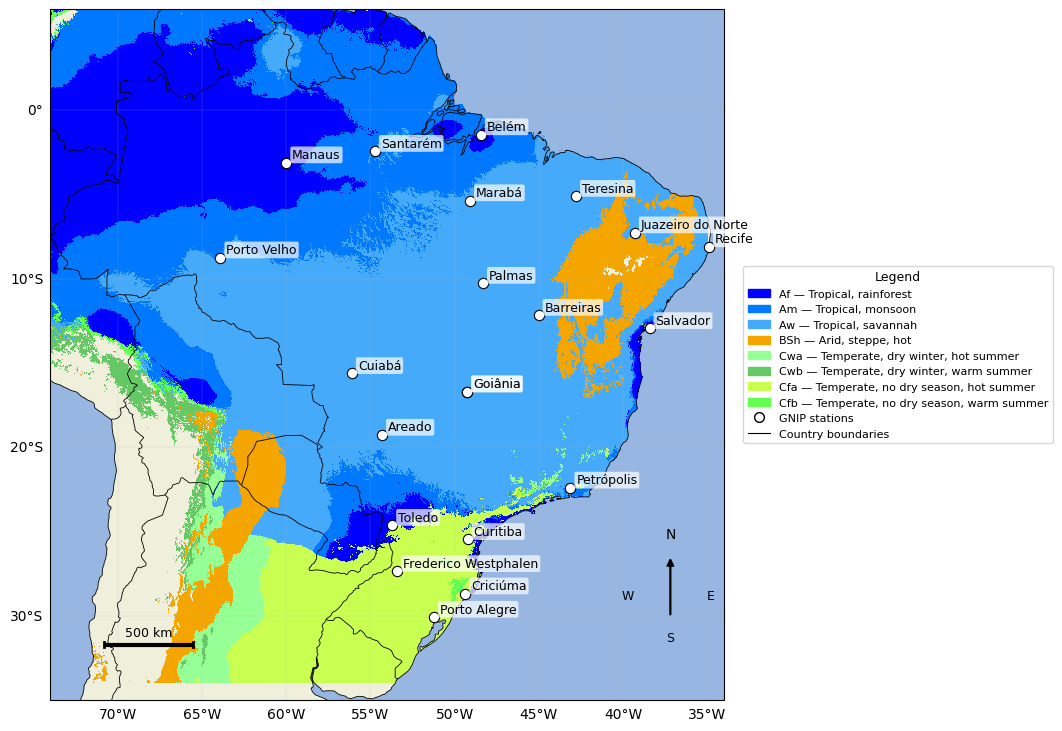

In [19]:
# ----------------------------
# 4) Plot
# ----------------------------
koppen_tif = "./koppen_geiger_0p00833333.tif"  # adjust path if needed

# Brazil-focused extent (lon_min, lon_max, lat_min, lat_max)
extent = (-74, -34, -35, 6)

fig = plt.figure(figsize=(10.5, 10.5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Base map features (no GIS needed)
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAND, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.6, zorder=3)

# Optional: states lines (Cartopy's "STATES" is US-only; keep off to avoid confusion)
# You can add admin-1 boundaries via Natural Earth if you want later.

# --- Read only raster window for extent (fast) ---
with rasterio.open(koppen_tif) as src:
    window = from_bounds(*extent, transform=src.transform)
    data = src.read(1, window=window)
    data = data.astype(float)

    # Mask all classes not present in Brazil
    mask_out = ~np.isin(data, BRAZIL_KOPPEN_CODES)
    data[mask_out] = np.nan
    transform = src.window_transform(window)

    # Mask nodata if present
    if src.nodata is not None:
        data = np.where(data == src.nodata, np.nan, data)

    rioshow(
        data,
        transform=transform,
        ax=ax,
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        zorder=1
    )
    # After reading 'data' for the map window:
    valid = data[~np.isnan(data)].astype(int)

    present_codes = np.unique(valid)
    present_codes = present_codes[(present_codes >= 1) & (present_codes <= 30)]
    present_codes = np.sort(present_codes)

    legend_patches = [
        mpatches.Patch(color=np.array(KOPPEN[c][2]) / 255.0,
                       label=f"{KOPPEN[c][0]} — {KOPPEN[c][1]}")
        for c in present_codes
    ]

# Stations
ax.scatter(
    stations["lon"], stations["lat"],
    transform=ccrs.PlateCarree(),
    s=55, marker="o",
    edgecolor="black", linewidth=0.8,
    color="white",
    zorder=6
)

for _, r in stations.iterrows():
    ax.text(
        r["lon"] + 0.35, r["lat"] + 0.25, r["station"],
        transform=ccrs.PlateCarree(),
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
        zorder=7
    )

# Gridlines (publication-friendly)
gl = ax.gridlines(draw_labels=True, linewidth=0.25, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Scale bar + compass rose
add_scalebar_km(ax, length_km=500)
add_compass_rose(ax)

# Legend: show only classes present in the plotted raster window (keeps it clean)
present_codes = np.unique(data[~np.isnan(data)].astype(int))
present_codes = present_codes[(present_codes >= 1) & (present_codes <= 30)]

legend_patches = []
for c in present_codes:
    code, desc, (R, G, B) = KOPPEN[c]
    patch = mpatches.Patch(color=np.array([R, G, B]) / 255.0, label=f"{code} — {desc}")
    legend_patches.append(patch)

from matplotlib.lines import Line2D

boundary_proxy = Line2D([0], [0], color="black", linewidth=0.8, label="Country boundaries")
station_proxy  = Line2D([0], [0], marker="o", color="black", markerfacecolor="white",
                        markersize=7, linestyle="None", label="GNIP stations")

handles = legend_patches + [station_proxy, boundary_proxy]

# Put legend outside the map (right side)
ax.legend(
    handles=handles,
    title="Legend",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    fontsize=8,
    title_fontsize=9
)

#ax.set_title("New GNIP stations over Köppen–Geiger climate classes (Brazil)", fontsize=13)
plt.tight_layout()
#plt.savefig("koppen_stations_brazil.png", dpi=600, bbox_inches="tight")
plt.savefig("koppen_20stations_brazil.png", dpi=600, bbox_inches="tight")
plt.show()

In [22]:
plt.savefig("koppen_stations_brazil.png", dpi=600, bbox_inches="tight", transparent=True)

<Figure size 640x480 with 0 Axes>

In [10]:
import pandas as pd

In [12]:
df_belem = pd.read_excel('./stations_data/Belem (GNIP-BELEM).xlsx', parse_dates=True)
df_poa = pd.read_excel('./stations_data/Porto Alegre (GNIP-POA).xlsx', parse_dates=True)
df_fw = pd.read_excel('./stations_data/Frederico Westphalen (GNIP-FW).xlsx', parse_dates=True)
df_go = pd.read_excel('./stations_data/Goiania (GNIP-GO).xlsx', parse_dates=True)
df_jua = pd.read_excel('./stations_data/Juazeiro do Norte (GNIP-JUA-CE).xlsx', parse_dates=True)
df_salv = pd.read_excel('./stations_data/Salvador (GNIP-Salv).xlsx', parse_dates=True)
df_pi = pd.read_excel('./stations_data/Teresina (GNIP-PI).xlsx', parse_dates=True)
df_areado = pd.read_excel('./stations_data/Areado.xlsx', parse_dates=True)
df_maraba = pd.read_excel('./stations_data/Maraba.xlsx', parse_dates=True)
df_barreiras = pd.read_excel('./stations_data/Barreiras.xlsx', parse_dates=True)
df_criciuma = pd.read_excel('./stations_data/Criciuma.xlsx', parse_dates=True)
df_cuiaba = pd.read_excel('./stations_data/Cuiaba.xlsx', parse_dates=True)
df_curitiba = pd.read_excel('./stations_data/Curitiba.xlsx', parse_dates=True)
df_manaus = pd.read_excel('./stations_data/Manaus.xlsx', parse_dates=True) 
df_palmas = pd.read_excel('./stations_data/Palmas.xlsx', parse_dates=True) 
df_petropolis = pd.read_excel('./stations_data/Petropolis.xlsx', parse_dates=True) 
df_portovelho = pd.read_excel('./stations_data/Porto Velho.xlsx', parse_dates=True) 
df_recife = pd.read_excel('./stations_data/Recife.xlsx', parse_dates=True) 
df_santarem = pd.read_excel('./stations_data/Santarem.xlsx', parse_dates=True) 
df_toledo = pd.read_excel('./stations_data/Toledo.xlsx', parse_dates=True) 

In [13]:
station_data_dict = {
    "Belem": df_belem,
    "Porto Alegre": df_poa,
    "Frederico Westphalen": df_fw,
    "Goiania": df_go,
    "Juazeiro do Norte": df_jua,
    "Salvador": df_salv,
    "Teresina": df_pi,
    "Areado": df_areado,
    "Marabá" : df_maraba,
    "Barreiras" : df_barreiras,
    "Criciúma": df_criciuma,
    "Cuiaba": df_cuiaba,
    "Curitiba": df_curitiba,
    "Manaus": df_manaus,
    "Palmas": df_palmas,
    "Petrópolis": df_petropolis,
    "Porto Velho": df_portovelho,
    "Recife": df_recife,
    "Santarém": df_santarem,
    "Toledo": df_toledo
}

In [14]:
import pandas as pd

coverage = []

for station, df in station_data_dict.items():
    start = df["date"].min()
    end = df["date"].max()

    coverage.append({
        "station": station,
        "start": start,
        "end": end
    })

coverage_df = pd.DataFrame(coverage)
coverage_df = coverage_df.sort_values("start")

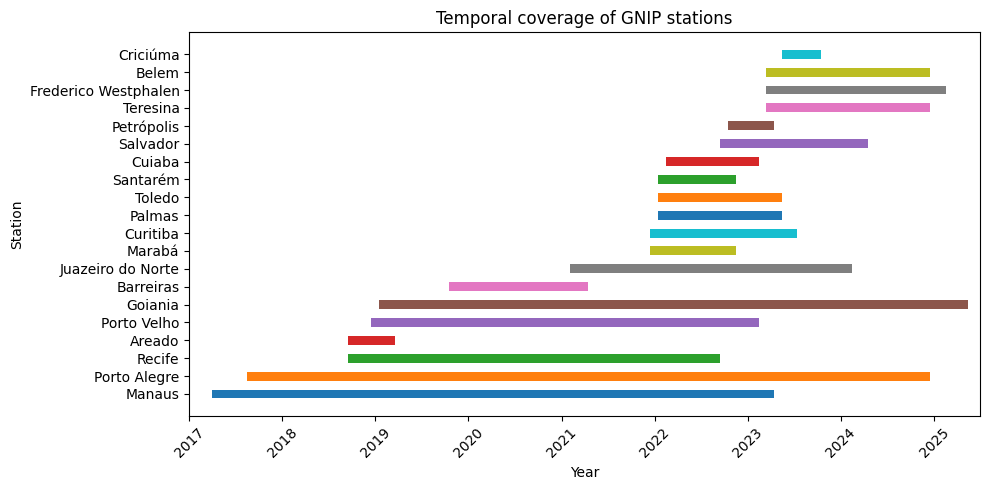

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,5))

for i, row in coverage_df.iterrows():
    ax.barh(
        y=row["station"],
        width=row["end"] - row["start"],
        left=row["start"],
        height=0.5
    )

# Force axis limits
ax.set_xlim(pd.Timestamp("2017-01-01"), pd.Timestamp("2025-06-30"))

# Nice year ticks
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_xlabel("Year")
ax.set_ylabel("Station")
ax.set_title("Temporal coverage of GNIP stations")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("temporal_coverage.png", dpi=600, bbox_inches="tight")
plt.show()

C:\Users\csilv\AppData\Local\Temp\ipykernel_17384\3148754464.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", n_stations)


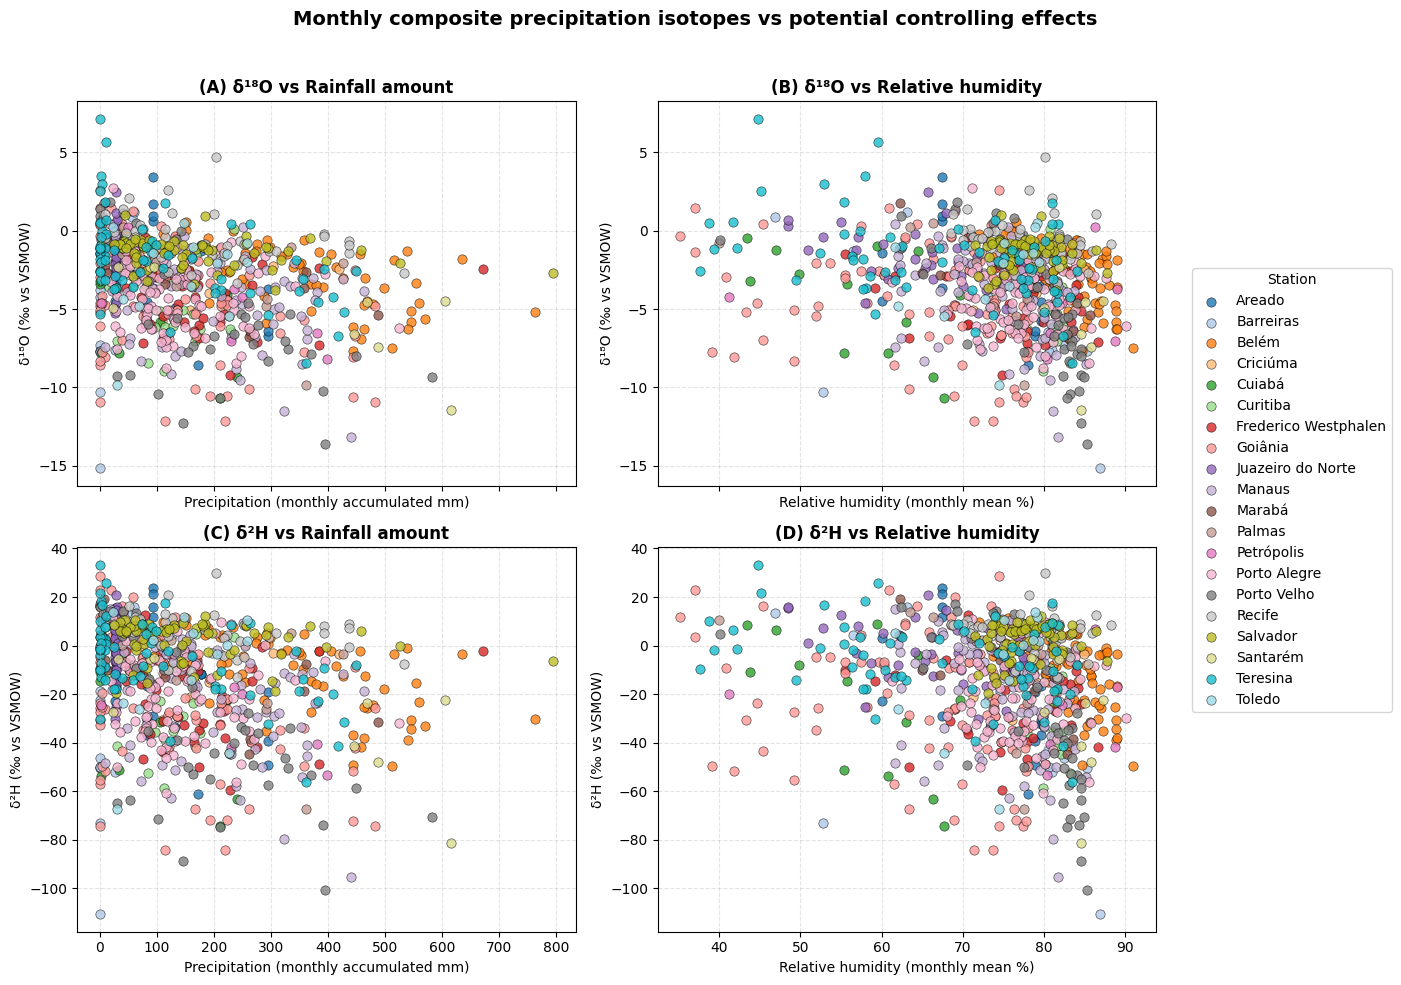

Figure saved to: C:\Users\csilv\Desktop\IAEA\Artigo-SGB\Isotopes_vs_Controlling_Effects_4panel.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 1. INPUT FILE
# =========================
file_path = "path/Water_Stable_Isotopes_Brazil_28Mar26.xlsx"   # change if needed
sheet_name = 0  # first sheet; replace with "Isotopes" if you prefer

# =========================
# 2. READ DATA
# =========================
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Expected columns
required_cols = [
    "Sample Date (monthly)",
    "Location",
    "δ²H (‰ vs VSMOW)",
    "δ¹⁸O (‰ vs VSMOW)",
    "Precipitation (monthly accumulated mm)",
    "Relative humidity (monthly mean %)"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Parse date
df["Sample Date (monthly)"] = pd.to_datetime(df["Sample Date (monthly)"], errors="coerce")

# Keep only needed columns
plot_df = df[required_cols].copy()

# Convert numeric columns safely
numeric_cols = [
    "δ²H (‰ vs VSMOW)",
    "δ¹⁸O (‰ vs VSMOW)",
    "Precipitation (monthly accumulated mm)",
    "Relative humidity (monthly mean %)"
]
for col in numeric_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

# Drop rows missing anything required for plotting
plot_df = plot_df.dropna(subset=numeric_cols + ["Location"])

# =========================
# 3. STYLE SETUP
# =========================
stations = sorted(plot_df["Location"].unique())
n_stations = len(stations)

# Build a color map with enough distinct colors
cmap = plt.cm.get_cmap("tab20", n_stations)
station_colors = {station: cmap(i) for i, station in enumerate(stations)}

# =========================
# 4. PLOT
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex="col")
(ax1, ax2), (ax3, ax4) = axes

panels = [
    (
        ax1,
        "Precipitation (monthly accumulated mm)",
        "δ¹⁸O (‰ vs VSMOW)",
        "(A) δ¹⁸O vs Rainfall amount"
    ),
    (
        ax2,
        "Relative humidity (monthly mean %)",
        "δ¹⁸O (‰ vs VSMOW)",
        "(B) δ¹⁸O vs Relative humidity"
    ),
    (
        ax3,
        "Precipitation (monthly accumulated mm)",
        "δ²H (‰ vs VSMOW)",
        "(C) δ²H vs Rainfall amount"
    ),
    (
        ax4,
        "Relative humidity (monthly mean %)",
        "δ²H (‰ vs VSMOW)",
        "(D) δ²H vs Relative humidity"
    ),
]

for ax, xcol, ycol, title in panels:
    for station in stations:
        sub = plot_df[plot_df["Location"] == station]
        ax.scatter(
            sub[xcol],
            sub[ycol],
            s=45,
            alpha=0.80,
            color=station_colors[station],
            edgecolor="black",
            linewidth=0.4,
            label=station
        )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xcol, fontsize=10)
    ax.set_ylabel(ycol, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.35)

# Create one shared legend outside the plot
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    title="Station",
    loc="center left",
    bbox_to_anchor=(.85, 0.5),
    frameon=True
)

fig.suptitle(
    "Monthly composite precipitation isotopes vs potential controlling effects",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 0.84, 0.96])

# =========================
# 5. SAVE FIGURE
# =========================
output_png = Path(file_path).with_name("Isotopes_vs_Controlling_Effects_4panel.png")
plt.savefig(output_png, dpi=600, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {output_png}")

C:\Users\csilv\AppData\Local\Temp\ipykernel_21152\3526317275.py:101: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("gist_rainbow", len(regions))


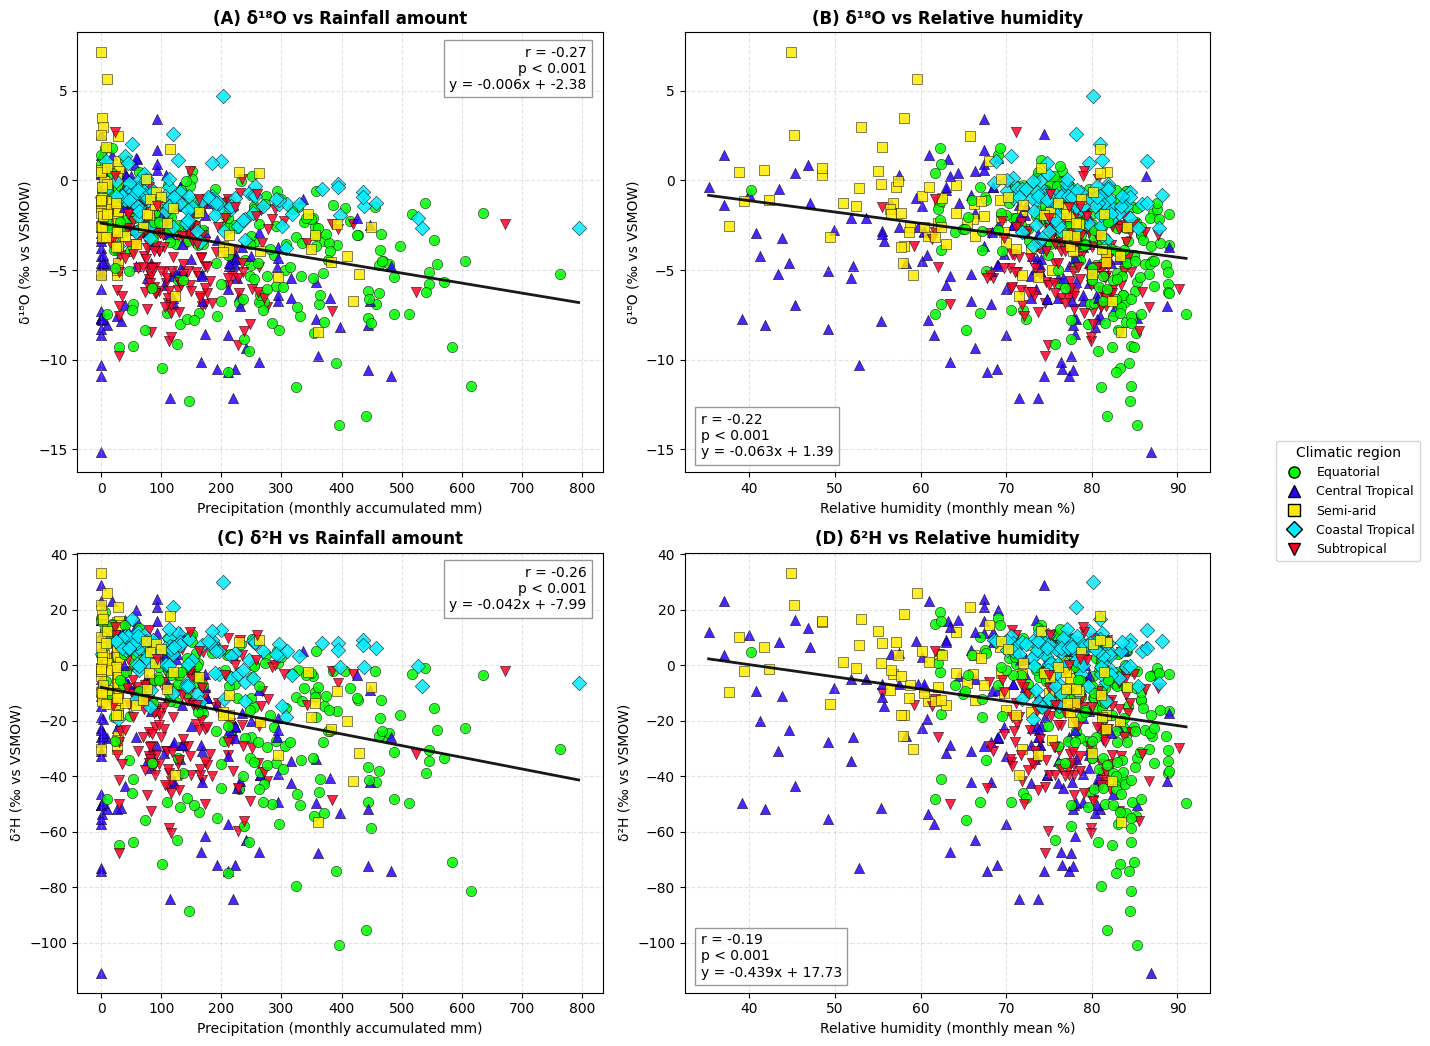

Saved: C:\Users\csilv\Desktop\IAEA\Artigo-SGB\Isotopes_vs_Rainfall_RH_4panel_regions_only.png


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr

# =========================
# 1. INPUT FILE
# =========================
file_path = "path/Water_Stable_Isotopes_Brazil_28Mar26.xlsx"
sheet_name = 0   # or "Isotopes"

# =========================
# 2. READ DATA
# =========================
df = pd.read_excel(file_path, sheet_name=sheet_name)

required_cols = [
    "Sample Date (monthly)",
    "Location",
    "δ²H (‰ vs VSMOW)",
    "δ¹⁸O (‰ vs VSMOW)",
    "Precipitation (monthly accumulated mm)",
    "Relative humidity (monthly mean %)"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["Sample Date (monthly)"] = pd.to_datetime(df["Sample Date (monthly)"], errors="coerce")

numeric_cols = [
    "δ²H (‰ vs VSMOW)",
    "δ¹⁸O (‰ vs VSMOW)",
    "Precipitation (monthly accumulated mm)",
    "Relative humidity (monthly mean %)"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

plot_df = df.dropna(subset=required_cols).copy()

# =========================
# 3. CLIMATIC REGIONS
# =========================
# Adjust if you want a different grouping
station_region = {
    "Belém": "Equatorial",
    "Manaus": "Equatorial",
    "Santarém": "Equatorial",
    "Marabá": "Equatorial",
    "Porto Velho": "Equatorial",

    "Goiânia": "Central Tropical",
    "Palmas": "Central Tropical",
    "Cuiabá": "Central Tropical",
    "Barreiras": "Central Tropical",
    "Areado": "Central Tropical",
    "Petrópolis": "Central Tropical",

    "Juazeiro do Norte": "Semi-arid",
    "Teresina": "Semi-arid",

    "Salvador": "Coastal Tropical",
    "Recife": "Coastal Tropical",

    "Porto Alegre": "Subtropical",
    "Frederico Westphalen": "Subtropical",
    "Curitiba": "Subtropical",
    "Criciúma": "Subtropical",
    "Toledo": "Subtropical",
}

# fallback if some station is missing above
plot_df["Region"] = plot_df["Location"].map(station_region).fillna("Other")

region_markers = {
    "Equatorial": "o",
    "Central Tropical": "^",
    "Semi-arid": "s",
    "Coastal Tropical": "D",
    "Subtropical": "v",
    "Other": "X"
}

# # Colors by station
# stations = sorted(plot_df["Location"].unique())
# cmap = plt.cm.get_cmap("tab20", len(stations))
# station_colors = {station: cmap(i) for i, station in enumerate(stations)}

regions = {
    "Equatorial",
    "Central Tropical",
    "Semi-arid",
    "Coastal Tropical",
    "Subtropical",
    "Other"
}

cmap = plt.cm.get_cmap("gist_rainbow", len(regions))
regions_colors = {region: cmap(i) for i, region in enumerate(regions)}

# =========================
# 4. HELPER FUNCTIONS
# =========================
def add_regression_and_stats(ax, x, y, xpos=0.03, ypos=0.95, ha="left", va="top"):
    """Add OLS trend line and Pearson statistics."""
    mask = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x)[mask]
    y = np.asarray(y)[mask]

    if len(x) < 3:
        ax.text(
            xpos, ypos, "n < 3",
            transform=ax.transAxes,
            ha=ha, va=va,
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )
        return

    # Linear fit
    slope, intercept = np.polyfit(x, y, 1)
    xx = np.linspace(np.min(x), np.max(x), 200)
    yy = slope * xx + intercept
    ax.plot(xx, yy, linestyle="-", linewidth=2, color="black", alpha=0.9)

    # Pearson correlation
    r, p = pearsonr(x, y)

    if p < 0.001:
        p_txt = "< 0.001"
    else:
        p_txt = f"= {p:.3f}"

    txt = f"r = {r:.2f}\np {p_txt}\ny = {slope:.3f}x + {intercept:.2f}"

    ax.text(
        xpos, ypos, txt,
        transform=ax.transAxes,
        ha=ha, va=va,
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
    )

def scatter_by_station_and_region(ax, xcol, ycol):
    """Plot points with station colors and region markers."""
    for station in stations:
        sub = plot_df[plot_df["Location"] == station]
        region = sub["Region"].iloc[0]
        marker = region_markers.get(region, "o")

        ax.scatter(
            sub[xcol],
            sub[ycol],
            s=55,
            alpha=0.85,
            color=regions_colors[region],
            edgecolor="black",
            linewidth=0.4,
            marker=marker,
            label=station
        )

# =========================
# 5. CREATE 4-PANEL FIGURE
# =========================
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
(ax1, ax2), (ax3, ax4) = axes

panel_specs = [
    (ax1, "Precipitation (monthly accumulated mm)", "δ¹⁸O (‰ vs VSMOW)", "(A) δ¹⁸O vs Rainfall amount"),
    (ax2, "Relative humidity (monthly mean %)",     "δ¹⁸O (‰ vs VSMOW)", "(B) δ¹⁸O vs Relative humidity"),
    (ax3, "Precipitation (monthly accumulated mm)", "δ²H (‰ vs VSMOW)",  "(C) δ²H vs Rainfall amount"),
    (ax4, "Relative humidity (monthly mean %)",     "δ²H (‰ vs VSMOW)",  "(D) δ²H vs Relative humidity"),
]

for ax, xcol, ycol, title in panel_specs:
    scatter_by_station_and_region(ax, xcol, ycol)

    # Position of stats box depends on x-variable
    if xcol == "Precipitation (monthly accumulated mm)":
        # right-top
        add_regression_and_stats(ax, plot_df[xcol], plot_df[ycol], xpos=0.97, ypos=0.97, ha="right", va="top")
    else:
        # left-bottom
        add_regression_and_stats(ax, plot_df[xcol], plot_df[ycol], xpos=0.03, ypos=0.03, ha="left", va="bottom")

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xcol, fontsize=10)
    ax.set_ylabel(ycol, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.35)

# =========================
# 6. LEGENDS
# =========================
# Station legend
# station_handles = [
#     plt.Line2D([0], [0], marker='o', color='w',
#                markerfacecolor=station_colors[s], markeredgecolor='black',
#                markersize=8, linestyle='None', label=s)
#     for s in stations
# ]

# Region legend
region_handles = [
    plt.Line2D([0], [0], marker=region_markers[r], color='black',
               markerfacecolor=regions_colors[r], markeredgecolor='black',
               markersize=8, linestyle='None', label=r)
    for r in region_markers
    if r in plot_df["Region"].unique()
]

# fig.legend(
#     handles=station_handles,
#     title="Station",
#     loc="center left",
#     bbox_to_anchor=(.85, 0.64),
#     frameon=True,
#     fontsize=9,
#     title_fontsize=10
# )

fig.legend(
    handles=region_handles,
    title="Climatic region",
    loc="center left",
    bbox_to_anchor=(.85, 0.5),
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# fig.suptitle(
#     "Monthly composite precipitation isotopes vs potential controlling effects",
#     fontsize=14,
#     fontweight="bold"
# )

plt.tight_layout(rect=[0, 0, 0.82, 0.96])

# =========================
# 7. SAVE
# =========================
output_png = Path(file_path).with_name("Isotopes_vs_Rainfall_RH_4panel_regions_only.png")
#output_tif = Path(file_path).with_name("Isotopes_vs_Rainfall_RH_4panel_regions.tif")

plt.savefig(output_png, dpi=600, bbox_inches="tight")
#plt.savefig(output_tif, dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {output_png}")
#print(f"Saved: {output_tif}")

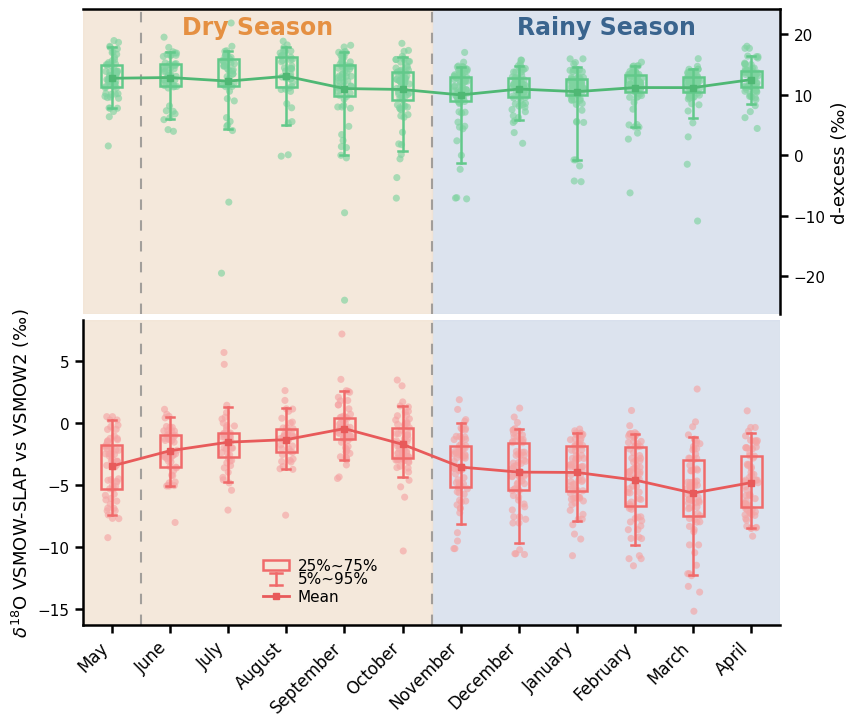

Saved: C:\Users\csilv\Desktop\IAEA\Artigo-SGB\Monthly_Isotopic_Composition_Seasonal_Boxplot.png


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

# =========================================================
# 1. INPUT
# =========================================================
file_path = "path/Water_Stable_Isotopes_Brazil_28Mar26.xlsx"
sheet_name = 0                                            # or "Isotopes"

# =========================================================
# 2. READ DATA
# =========================================================
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Expected columns
required_cols = [
    "Sample Date (monthly)",
    "Location",
    "δ²H (‰ vs VSMOW)",
    "δ¹⁸O (‰ vs VSMOW)"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Parse dates
df["Sample Date (monthly)"] = pd.to_datetime(df["Sample Date (monthly)"], errors="coerce")

# Convert numeric columns
df["δ²H (‰ vs VSMOW)"] = pd.to_numeric(df["δ²H (‰ vs VSMOW)"], errors="coerce")
df["δ¹⁸O (‰ vs VSMOW)"] = pd.to_numeric(df["δ¹⁸O (‰ vs VSMOW)"], errors="coerce")

# Drop incomplete rows
df = df.dropna(subset=["Sample Date (monthly)", "δ²H (‰ vs VSMOW)", "δ¹⁸O (‰ vs VSMOW)"]).copy()

# Compute d-excess
df["d-excess (‰)"] = df["δ²H (‰ vs VSMOW)"] - 8 * df["δ¹⁸O (‰ vs VSMOW)"]

# =========================================================
# 3. MONTH ORDER (example: hydrological year May -> April)
#    Change this if you want Jan -> Dec
# =========================================================
month_order = [5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4]
month_labels = ["May", "June", "July", "August", "September", "October",
                "November", "December", "January", "February", "March", "April"]

# Map month to plotting position
month_to_pos = {m: i + 1 for i, m in enumerate(month_order)}

df["month"] = df["Sample Date (monthly)"].dt.month
df["year"] = df["Sample Date (monthly)"].dt.year
df = df[df["month"].isin(month_order)].copy()
df["xpos"] = df["month"].map(month_to_pos)

# =========================================================
# 4. SEASON DEFINITIONS
#    Adjust these months to your study area
#    Example here matches the visual style of the Cuba figure:
#    Rainy season = May-Oct
#    Dry season   = Nov-Apr
# =========================================================
dry_months = [5, 6, 7, 8, 9, 10]
rainy_months   = [11, 12, 1, 2, 3, 4]

# Positions for season shading
rainy_start = month_to_pos[rainy_months[0]] - 0.5
rainy_end   = month_to_pos[rainy_months[-1]] + 0.5
dry_start   = month_to_pos[dry_months[0]] - 0.5
dry_end     = month_to_pos[dry_months[-1]] + 0.5

# =========================================================
# 5. HELPER: DRAW MONTHLY SUMMARY
# =========================================================
def draw_monthly_summary(ax, data, value_col, color_points, color_box, color_line,
                         annotate_extremes=False, n_extremes=5):
    means = []
    x_positions = []

    for m in month_order:
        sub = data[data["month"] == m][value_col].dropna().values
        x = month_to_pos[m]
        x_positions.append(x)

        if len(sub) == 0:
            means.append(np.nan)
            continue

        # Jittered scatter
        jitter = np.random.uniform(-0.12, 0.12, size=len(sub))
        ax.scatter(
            np.full(len(sub), x) + jitter,
            sub,
            s=26,
            color=color_points,
            alpha=0.65,
            edgecolor="none",
            zorder=2
        )

        # Percentiles
        p05 = np.percentile(sub, 5)
        p25 = np.percentile(sub, 25)
        p50 = np.percentile(sub, 50)
        p75 = np.percentile(sub, 75)
        p95 = np.percentile(sub, 95)
        mean = np.mean(sub)
        means.append(mean)

        # Whisker
        ax.plot([x, x], [p05, p95], color=color_box, linewidth=1.8, zorder=3)
        ax.plot([x - 0.07, x + 0.07], [p05, p05], color=color_box, linewidth=1.8, zorder=3)
        ax.plot([x - 0.07, x + 0.07], [p95, p95], color=color_box, linewidth=1.8, zorder=3)

        # 25-75 box
        rect = Rectangle(
            (x - 0.18, p25),
            0.36,
            p75 - p25,
            fill=False,
            edgecolor=color_box,
            linewidth=1.8,
            zorder=4
        )
        ax.add_patch(rect)

    # Mean line
    ax.plot(
        x_positions,
        means,
        marker="s",
        markersize=4,
        linestyle="-",
        linewidth=2,
        color=color_line,
        zorder=5
    )

    # Optional annotation of extreme depleted δ18O values
    if annotate_extremes:
        extreme_df = data.nsmallest(n_extremes, value_col).copy()
        for _, row in extreme_df.iterrows():
            label = f"{row['Location']}\n{row['Sample Date (monthly)'].year}"
            ax.annotate(
                label,
                xy=(row["xpos"], row[value_col]),
                xytext=(row["xpos"] - 0.3, row[value_col] - 1.0),
                fontsize=8,
                ha="right",
                va="top",
                arrowprops=dict(arrowstyle="-", lw=0.7, color="gray"),
                color="black",
                zorder=6
            )

# =========================================================
# 6. CREATE FIGURE
# =========================================================
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(9, 8), sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.02}
)

# Colors similar to the original style
green_pts = "#7FD3A0"
green_box = "#62C98A"
green_line = "#4FB874"

red_pts = "#F4A5A5"
red_box = "#F06A6A"
red_line = "#E85A5A"

# Season shading
for ax in [ax_top, ax_bottom]:
    ax.axvspan(rainy_start, rainy_end, color="#D6DEEC", alpha=0.85, zorder=0)
    ax.axvspan(dry_start, dry_end, color="#F3E4D5", alpha=0.85, zorder=0)

    # Vertical dashed lines delimiting seasons
    ax.axvline(month_to_pos[6] - 0.5, color="gray", lw=1.5, ls=(0, (5, 5)), alpha=0.7)
    ax.axvline(month_to_pos[11] - 0.5, color="gray", lw=1.5, ls=(0, (5, 5)), alpha=0.7)

# Top panel: d-excess
draw_monthly_summary(
    ax_top,
    df,
    "d-excess (‰)",
    color_points=green_pts,
    color_box=green_box,
    color_line=green_line,
    annotate_extremes=False
)

# Bottom panel: δ18O
draw_monthly_summary(
    ax_bottom,
    df,
    "δ¹⁸O (‰ vs VSMOW)",
    color_points=red_pts,
    color_box=red_box,
    color_line=red_line,
    annotate_extremes=False,   # set False if you don't want labels
    n_extremes=5
)

# =========================================================
# 7. FORMAT AXES
# =========================================================
# Top panel formatting
ax_top.set_ylabel("d-excess (‰)", fontsize=13)
ax_top.yaxis.set_label_position("right")
ax_top.yaxis.tick_right()
ax_top.spines["left"].set_visible(False)
ax_top.spines["bottom"].set_visible(False)
ax_top.tick_params(axis="y", labelsize=11, width=1.8, length=6)
ax_top.tick_params(axis="x", bottom=False, labelbottom=False)

# Bottom panel formatting
ax_bottom.set_ylabel(r"$\delta^{18}$O VSMOW-SLAP vs VSMOW2 (‰)", fontsize=13)
ax_bottom.spines["top"].set_visible(False)
ax_bottom.spines["right"].set_visible(False)
ax_bottom.tick_params(axis="both", labelsize=11, width=1.8, length=6)

# Shared x-axis
ax_bottom.set_xlim(0.5, 12.5)
ax_bottom.set_xticks(range(1, 13))
ax_bottom.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=12)

# Season labels
ax_top.text((rainy_start + rainy_end) / 2, ax_top.get_ylim()[1] * 0.96,
            "Rainy Season", ha="center", va="top",
            fontsize=17, fontweight="bold", color="#3A648E")

ax_top.text((dry_start + dry_end) / 2, ax_top.get_ylim()[1] * 0.96,
            "Dry Season", ha="center", va="top",
            fontsize=17, fontweight="bold", color="#E59042")

# Legend-like explanation (drawn manually to mimic the style)
x0 = 3.6
y0 = ax_bottom.get_ylim()[0] + 0.18 * (ax_bottom.get_ylim()[1] - ax_bottom.get_ylim()[0])

# 25-75 box
ax_bottom.add_patch(Rectangle((x0, y0), 0.45, 0.8, fill=False, edgecolor=red_box, linewidth=1.8))
ax_bottom.text(x0 + 0.6, y0 + 0.4, "25%~75%", va="center", fontsize=11)

# 5-95 whisker
ax_bottom.plot([x0 + 0.225, x0 + 0.225], [y0 - 1.2, y0 - 0.2], color=red_box, linewidth=1.8)
ax_bottom.plot([x0 + 0.12, x0 + 0.33], [y0 - 1.2, y0 - 1.2], color=red_box, linewidth=1.8)
ax_bottom.plot([x0 + 0.12, x0 + 0.33], [y0 - 0.2, y0 - 0.2], color=red_box, linewidth=1.8)
ax_bottom.text(x0 + 0.6, y0 - 0.7, "5%~95%", va="center", fontsize=11)

# mean line
ax_bottom.plot([x0, x0 + 0.45], [y0 - 2.1, y0 - 2.1], color=red_line, linewidth=2)
ax_bottom.plot(x0 + 0.225, y0 - 2.1, marker="s", color=red_line, markersize=5)
ax_bottom.text(x0 + 0.6, y0 - 2.1, "Mean", va="center", fontsize=11)

# Remove unnecessary spines thickness
for ax in [ax_top, ax_bottom]:
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

# =========================================================
# 8. SAVE
# =========================================================
out_png = Path(file_path).with_name("Monthly_Isotopic_Composition_Seasonal_Boxplot.png")
#out_tif = Path(file_path).with_name("Monthly_Isotopic_Composition_Seasonal_Boxplot.tif")

plt.savefig(out_png, dpi=600, bbox_inches="tight")
#plt.savefig(out_tif, dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")
#print(f"Saved: {out_tif}")

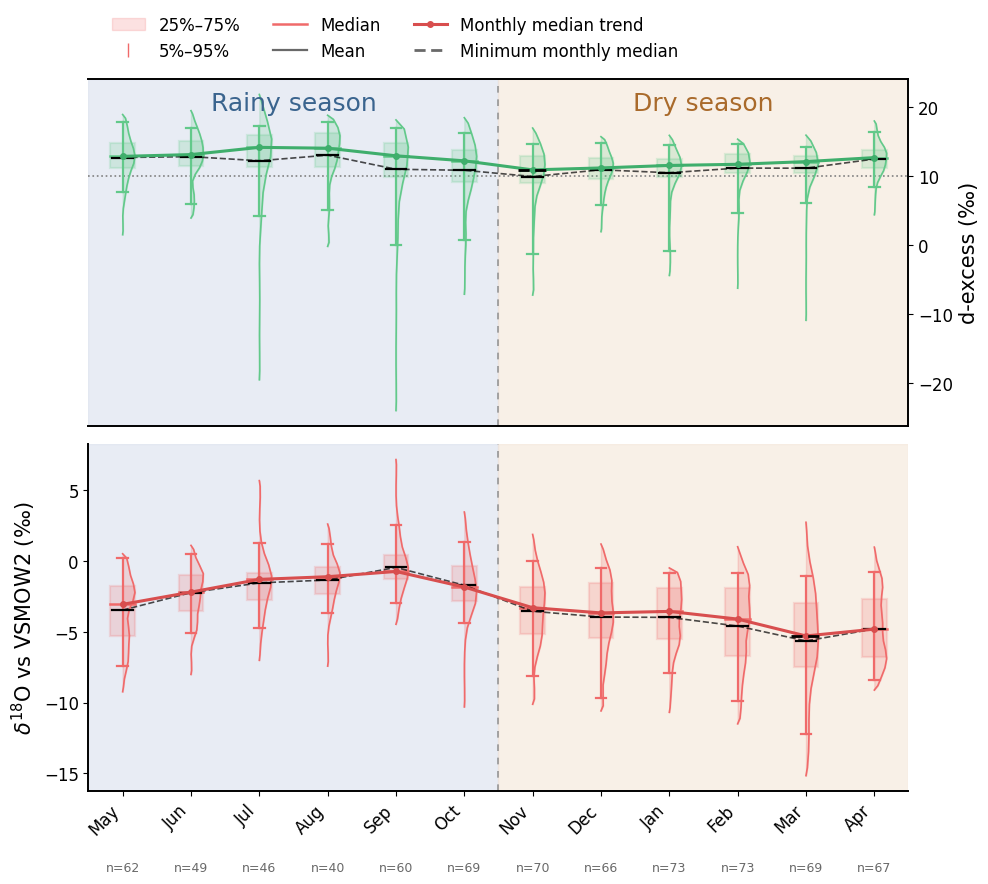

Saved: C:\Users\csilv\Desktop\IAEA\Artigo-SGB\Monthly_Isotopic_Composition_Seasonal_Boxplot_improved_v2.png


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib import transforms
from pathlib import Path

# =========================================================
# 1. INPUT
# =========================================================
file_path = "path/Water_Stable_Isotopes_Brazil_28Mar26.xlsx"
sheet_name = 0

# =========================================================
# 2. READ DATA
# =========================================================
df = pd.read_excel(file_path, sheet_name=sheet_name)

required_cols = [
    "Sample Date (monthly)",
    "Location",
    "δ²H (‰ vs VSMOW)",
    "δ¹⁸O (‰ vs VSMOW)"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["Sample Date (monthly)"] = pd.to_datetime(df["Sample Date (monthly)"], errors="coerce")
df["δ²H (‰ vs VSMOW)"] = pd.to_numeric(df["δ²H (‰ vs VSMOW)"], errors="coerce")
df["δ¹⁸O (‰ vs VSMOW)"] = pd.to_numeric(df["δ¹⁸O (‰ vs VSMOW)"], errors="coerce")

df = df.dropna(subset=["Sample Date (monthly)", "δ²H (‰ vs VSMOW)", "δ¹⁸O (‰ vs VSMOW)"]).copy()
df["d-excess (‰)"] = df["δ²H (‰ vs VSMOW)"] - 8 * df["δ¹⁸O (‰ vs VSMOW)"]

# =========================================================
# 3. MONTH ORDER
# =========================================================
month_order = [5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4]
month_labels = ["May", "Jun", "Jul", "Aug", "Sep", "Oct",
                "Nov", "Dec", "Jan", "Feb", "Mar", "Apr"]

month_to_pos = {m: i + 1 for i, m in enumerate(month_order)}

df["month"] = df["Sample Date (monthly)"].dt.month
df["year"] = df["Sample Date (monthly)"].dt.year
df = df[df["month"].isin(month_order)].copy()
df["xpos"] = df["month"].map(month_to_pos)

# =========================================================
# 4. SEASONS
# =========================================================
rainy_months = [5, 6, 7, 8, 9, 10]
dry_months   = [11, 12, 1, 2, 3, 4]

rainy_start = month_to_pos[rainy_months[0]] - 0.5
rainy_end   = month_to_pos[rainy_months[-1]] + 0.5
dry_start   = month_to_pos[dry_months[0]] - 0.5
dry_end     = month_to_pos[dry_months[-1]] + 0.5

# =========================================================
# 5. STYLES
# =========================================================
green_pts = "#7FD3A0"
green_box = "#62C98A"
green_line = "#3FAE6C"

red_pts = "#F4A5A5"
red_box = "#F06A6A"
red_line = "#D84E4E"

# =========================================================
# 6. HELPERS
# =========================================================
def smooth_hist(counts, passes=2):
    counts = counts.astype(float)
    kernel = np.array([1, 2, 1], dtype=float)
    kernel /= kernel.sum()
    for _ in range(passes):
        counts = np.convolve(counts, kernel, mode="same")
    return counts

def draw_half_violin(ax, values, xpos, color, side="right", width=0.20, bins=16, alpha=0.18):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if len(values) < 3:
        return

    counts, edges = np.histogram(values, bins=bins)
    counts = smooth_hist(counts, passes=2)
    if counts.max() == 0:
        return

    widths = width * counts / counts.max()
    y = 0.5 * (edges[:-1] + edges[1:])
    y_plot = np.r_[edges[0], y, edges[-1]]
    w_plot = np.r_[0, widths, 0]

    if side == "right":
        x_outer = xpos + w_plot
        ax.fill_betweenx(y_plot, xpos, x_outer, color=color, alpha=alpha, zorder=1)
        ax.plot(x_outer, y_plot, color=color, lw=1.2, zorder=2)
    else:
        x_outer = xpos - w_plot
        ax.fill_betweenx(y_plot, x_outer, xpos, color=color, alpha=alpha, zorder=1)
        ax.plot(x_outer, y_plot, color=color, lw=1.2, zorder=2)

def monthly_stats(data, value_col):
    rows = []
    for m in month_order:
        sub = data.loc[data["month"] == m, value_col].dropna().values
        if len(sub) == 0:
            rows.append([m, np.nan, np.nan, np.nan, np.nan, np.nan, 0])
            continue
        rows.append([
            m,
            np.percentile(sub, 25),
            np.percentile(sub, 50),
            np.percentile(sub, 75),
            np.mean(sub),
            np.std(sub, ddof=1) if len(sub) > 1 else np.nan,
            len(sub)
        ])
    out = pd.DataFrame(rows, columns=["month", "q25", "median", "q75", "mean", "sd", "n"])
    out["x"] = out["month"].map(month_to_pos)
    return out

def draw_monthly_summary(ax, data, value_col, color_box, color_line, violin_color,
                         show_reference=None, annotate_min_median=False):
    stats = monthly_stats(data, value_col)

    x_positions = []
    means = []
    medians = []

    for m in month_order:
        sub = data.loc[data["month"] == m, value_col].dropna().values
        x = month_to_pos[m]

        x_positions.append(x)
        if len(sub) == 0:
            means.append(np.nan)
            medians.append(np.nan)
            continue

        draw_half_violin(ax, sub, x, violin_color, side="right", width=0.18, bins=16, alpha=0.20)

        p05 = np.percentile(sub, 5)
        p25 = np.percentile(sub, 25)
        p50 = np.percentile(sub, 50)
        p75 = np.percentile(sub, 75)
        p95 = np.percentile(sub, 95)
        mean = np.mean(sub)

        means.append(mean)
        medians.append(p50)

        # whiskers
        ax.plot([x, x], [p05, p95], color=color_box, linewidth=1.6, zorder=3)
        ax.plot([x - 0.08, x + 0.08], [p05, p05], color=color_box, linewidth=1.6, zorder=3)
        ax.plot([x - 0.08, x + 0.08], [p95, p95], color=color_box, linewidth=1.6, zorder=3)

        # box
        rect = Rectangle(
            (x - 0.18, p25),
            0.36,
            p75 - p25,
            facecolor=color_box,
            edgecolor=color_box,
            alpha=0.20,
            linewidth=1.6,
            zorder=4
        )
        ax.add_patch(rect)

        # median
        ax.plot([x - 0.18, x + 0.18], [p50, p50], color=color_box, linewidth=1.8, zorder=5)

        # mean
        ax.plot([x - 0.15, x + 0.15], [mean, mean], color="black", linewidth=1.6, zorder=6)

    # monthly median line
    ax.plot(x_positions, medians, color=color_line, lw=2.2, marker="o", ms=4, zorder=7, label="Monthly median")

    # optional mean line
    ax.plot(x_positions, means, color="black", lw=1.2, ls="--", alpha=0.7, zorder=6, label="Monthly mean")

    # optional reference line
    if show_reference is not None:
        ax.axhline(show_reference, color="gray", lw=1.2, ls=":", zorder=0)

    # annotate month of minimum median
    if annotate_min_median:
        valid = stats.dropna(subset=["median"])
        if not valid.empty:
            row = valid.loc[valid["median"].idxmin()]
            ax.annotate(
                "minimum monthly median",
                xy=(row["x"], row["median"]),
                xytext=(row["x"] + 0.35, row["median"]),
                fontsize=9,
                ha="left",
                va="center",
                arrowprops=dict(arrowstyle="-", lw=0.8, color="gray"),
                color="black",
                zorder=8
            )

    return stats

def add_monthly_n(ax, data):
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    for m in month_order:
        n = data.loc[data["month"] == m].shape[0]
        ax.text(month_to_pos[m], -0.14, f"n={n}", transform=trans,
                ha="center", va="top", fontsize=9, color="dimgray")

# =========================================================
# 7. FIGURE
# =========================================================
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(10, 8.8), sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.05}
)

for ax in [ax_top, ax_bottom]:
    ax.axvspan(rainy_start, rainy_end, color="#D6DEEC", alpha=0.55, zorder=0)
    ax.axvspan(dry_start, dry_end, color="#F3E4D5", alpha=0.55, zorder=0)
    ax.axvline(month_to_pos[11] - 0.5, color="gray", lw=1.2, ls=(0, (4, 4)), alpha=0.8)

# Top: d-excess
stats_d = draw_monthly_summary(
    ax_top, df, "d-excess (‰)",
    color_box=green_box,
    color_line=green_line,
    violin_color=green_box,
    show_reference=10,
    annotate_min_median=False   # we will add a manual cleaner annotation below
)

# Bottom: δ18O
stats_o18 = draw_monthly_summary(
    ax_bottom, df, "δ¹⁸O (‰ vs VSMOW)",
    color_box=red_box,
    color_line=red_line,
    violin_color=red_box,
    show_reference=None,
    annotate_min_median=False   # manual cleaner annotation below
)

# =========================================================
# 8. AXIS FORMATTING
# =========================================================
ax_top.set_ylabel("d-excess (‰)", fontsize=15)
ax_top.yaxis.set_label_position("right")
ax_top.yaxis.tick_right()
ax_top.spines["left"].set_visible(False)
ax_top.tick_params(axis="x", bottom=False, labelbottom=False)
ax_top.tick_params(axis="y", labelsize=12)

ax_bottom.set_ylabel(r"$\delta^{18}$O vs VSMOW2 (‰)", fontsize=15)
ax_bottom.spines["right"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_bottom.tick_params(axis="both", labelsize=12)

ax_bottom.set_xlim(0.5, 12.5)
ax_bottom.set_xticks(range(1, 13))
ax_bottom.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=12)

# Add more room below x tick labels for n values
add_monthly_n(ax_bottom, df)

# Move the n labels farther down
trans_n = transforms.blended_transform_factory(ax_bottom.transData, ax_bottom.transAxes)
for txt in ax_bottom.texts[-12:]:
    txt.set_y(-0.20)

# =========================================================
# 9. SEASON LABELS (moved lower, centered in panels)
# =========================================================
trans_top = transforms.blended_transform_factory(ax_top.transData, ax_top.transAxes)

ax_top.text(
    (rainy_start + rainy_end) / 2, 0.93, "Rainy season",
    transform=trans_top,
    ha="center", va="center",
    fontsize=18, color="#3A648E"
)

ax_top.text(
    (dry_start + dry_end) / 2, 0.93, "Dry season",
    transform=trans_top,
    ha="center", va="center",
    fontsize=18, color="#A96A2B"
)

# =========================================================
# 10. CLEANER MANUAL ANNOTATIONS
# =========================================================
# Mark minimum monthly median with dashed horizontal segment
valid_d = stats_d.dropna(subset=["median"])
row_d = valid_d.loc[valid_d["median"].idxmin()]
ax_top.plot(
    [row_d["x"] - 0.22, row_d["x"] + 0.22],
    [row_d["median"], row_d["median"]],
    color="black",
    lw=2.0,
    ls=(0, (4, 2)),
    zorder=8
)

valid_o = stats_o18.dropna(subset=["median"])
row_o = valid_o.loc[valid_o["median"].idxmin()]
ax_bottom.plot(
    [row_o["x"] - 0.22, row_o["x"] + 0.22],
    [row_o["median"], row_o["median"]],
    color="black",
    lw=2.0,
    ls=(0, (4, 2)),
    zorder=8
)

# =========================================================
# 11. REFERENCE LINE LABEL (move away from right ticks)
# =========================================================
# remove the automatic text inside draw_monthly_summary if present in your version,
# then add this explicit label:
trans_ref = transforms.blended_transform_factory(ax_top.transAxes, ax_top.transData)
ax_top.text(
    1.02, 10, "", #"10‰",
    transform=trans_ref,
    ha="left", va="center",
    fontsize=11, color="gray",
    clip_on=False
)

# =========================================================
# 12. SPINES
# =========================================================
for ax in [ax_top, ax_bottom]:
    for spine in ax.spines.values():
        spine.set_linewidth(1.4)

# =========================================================
# 13. LEGEND (move outside the plotting region)
# =========================================================
legend_handles = [
    Rectangle((0, 0), 1, 1, facecolor=red_box, edgecolor=red_box, alpha=0.20, label="25%–75%"),
    Line2D([0], [0], color=red_box, lw=1.6, marker="|", markersize=10, linestyle="None", label="5%–95%"),
    Line2D([0], [0], color=red_box, lw=1.8, label="Median"),
    Line2D([0], [0], color="dimgray", lw=1.6, label="Mean"),
    Line2D([0], [0], color=red_line, lw=2.2, marker="o", markersize=4, label="Monthly median trend"),
    Line2D([0], [0], color="dimgray", lw=2.0, ls=(0, (4, 2)), label="Minimum monthly median"),
]

ax_top.legend(
    handles=legend_handles,
    loc="lower left",
    bbox_to_anchor=(0.01, 1.01),
    frameon=False,
    ncol=3,
    fontsize=12
)

# =========================================================
# 14. SAVE
# =========================================================
out_png = Path(file_path).with_name("Monthly_Isotopic_Composition_Seasonal_Boxplot_improved_v2.png")

plt.subplots_adjust(left=0.10, right=0.92, top=0.95, bottom=0.14)
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")

C:\Users\csilv\AppData\Local\Temp\ipykernel_17088\2341312283.py:322: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


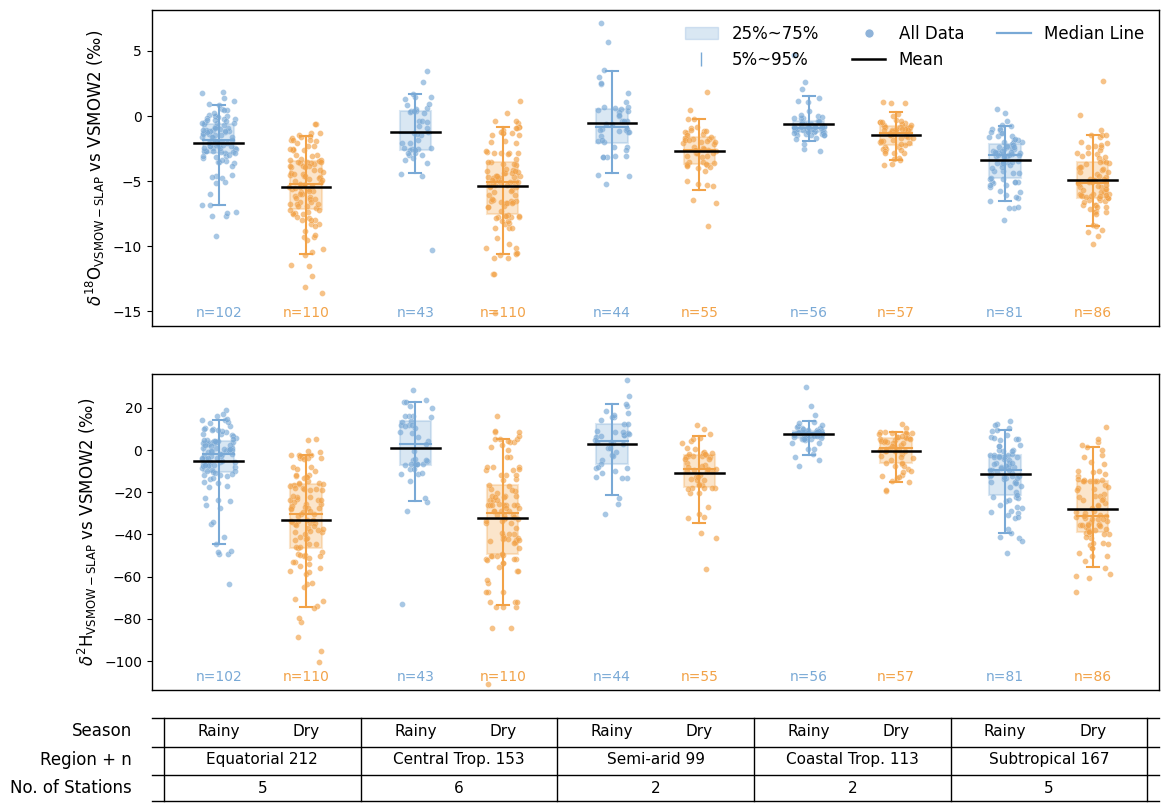

Saved: C:\Users\csilv\Desktop\IAEA\Artigo-SGB\Regional_Seasonal_Boxplots_Isotopes_5regions.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib import transforms
from pathlib import Path

# =========================================================
# 1. INPUT
# =========================================================
file_path = "path/Water_Stable_Isotopes_Brazil_28Mar26.xlsx"
sheet_name = 0

# =========================================================
# 2. READ DATA
# =========================================================
df = pd.read_excel(file_path, sheet_name=sheet_name)

required_cols = [
    "Sample Date (monthly)",
    "Location",
    "δ²H (‰ vs VSMOW)",
    "δ¹⁸O (‰ vs VSMOW)"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["Sample Date (monthly)"] = pd.to_datetime(df["Sample Date (monthly)"], errors="coerce")
df["δ²H (‰ vs VSMOW)"] = pd.to_numeric(df["δ²H (‰ vs VSMOW)"], errors="coerce")
df["δ¹⁸O (‰ vs VSMOW)"] = pd.to_numeric(df["δ¹⁸O (‰ vs VSMOW)"], errors="coerce")
df = df.dropna(subset=required_cols).copy()

# =========================================================
# 3. REGION MAPPING
# =========================================================
station_region = {
    "Belém": "Equatorial",
    "Manaus": "Equatorial",
    "Santarém": "Equatorial",
    "Marabá": "Equatorial",
    "Porto Velho": "Equatorial",

    "Goiânia": "Central Trop.",
    "Palmas": "Central Trop.",
    "Cuiabá": "Central Trop.",
    "Barreiras": "Central Trop.",
    "Areado": "Central Trop.",
    "Petrópolis": "Central Trop.",

    "Juazeiro do Norte": "Semi-arid",
    "Teresina": "Semi-arid",

    "Salvador": "Coastal Trop.",
    "Recife": "Coastal Trop.",

    "Porto Alegre": "Subtropical",
    "Frederico Westphalen": "Subtropical",
    "Curitiba": "Subtropical",
    "Criciúma": "Subtropical",
    "Toledo": "Subtropical",
}

df["Region"] = df["Location"].map(station_region)
df = df.dropna(subset=["Region"]).copy()

region_order = [
    "Equatorial",
    "Central Trop.",
    "Semi-arid",
    "Coastal Trop.",
    "Subtropical"
]

# =========================================================
# 4. SEASON DEFINITION
# =========================================================
df["month"] = df["Sample Date (monthly)"].dt.month
df["Season"] = np.where(df["month"].isin([5, 6, 7, 8, 9, 10]), "Rainy", "Dry")
season_order = ["Rainy", "Dry"]

# =========================================================
# 5. STYLES
# =========================================================
season_colors = {
    "Rainy": "#79A9D6",
    "Dry":   "#F2A247"
}

# =========================================================
# 6. X POSITIONS (FIXED SPACING)
# =========================================================
# Make within-region spacing reasonable and inter-region gap smaller
within_gap = 0.72   # distance between Rainy and Dry centers
region_gap = 0.45   # extra gap between regions

x_positions = {}
region_centers = {}
region_boundaries = []

current_x = 1.0
for region in region_order:
    x_rainy = current_x
    x_dry = current_x + within_gap

    x_positions[(region, "Rainy")] = x_rainy
    x_positions[(region, "Dry")] = x_dry
    region_centers[region] = (x_rainy + x_dry) / 2

    # boundary covers both seasonal groups with a little padding
    left = x_rainy - 0.45
    right = x_dry + 0.45
    region_boundaries.append((left, right))

    current_x = x_dry + region_gap + 0.45

xmin_plot = region_boundaries[0][0] - 0.10
xmax_plot = region_boundaries[-1][1] + 0.10

# =========================================================
# 7. HELPERS
# =========================================================
def draw_group(ax, values, xpos, color, jitter_width=0.14, box_width=0.26):
    values = np.asarray(values)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return

    jitter = np.random.uniform(-jitter_width, jitter_width, size=len(values))
    ax.scatter(
        np.full(len(values), xpos) + jitter,
        values,
        s=18,
        color=color,
        alpha=0.65,
        edgecolor="white",
        linewidth=0.2,
        zorder=3
    )

    q25 = np.percentile(values, 25)
    q50 = np.percentile(values, 50)
    q75 = np.percentile(values, 75)
    p05 = np.percentile(values, 5)
    p95 = np.percentile(values, 95)
    mean = np.mean(values)

    # whisker
    ax.plot([xpos, xpos], [p05, p95], color=color, linewidth=1.5, zorder=4)
    ax.plot([xpos - 0.05, xpos + 0.05], [p05, p05], color=color, linewidth=1.5, zorder=4)
    ax.plot([xpos - 0.05, xpos + 0.05], [p95, p95], color=color, linewidth=1.5, zorder=4)

    # box
    rect = Rectangle(
        (xpos - box_width / 2, q25),
        box_width,
        q75 - q25,
        facecolor=color,
        edgecolor=color,
        alpha=0.28,
        linewidth=1.5,
        zorder=5
    )
    ax.add_patch(rect)

    # median
    ax.plot([xpos - box_width / 2, xpos + box_width / 2], [q50, q50],
            color=color, linewidth=1.5, zorder=6)

    # mean
    ax.plot([xpos - 0.20, xpos + 0.20], [mean, mean],
            color="black", linewidth=1.8, zorder=7)


def add_bottom_table(ax, grouped_counts, grouped_station_counts):
    # y positions in axes coordinates
    y1 = -0.13
    y2 = -0.22
    y3 = -0.31

    # Use blended transform: x in data coords, y in axes coords
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)

    # Left row labels in axes coords
    ax.text(-0.02, y1, "Season", transform=ax.transAxes, ha="right", va="center", fontsize=12)
    ax.text(-0.02, y2, "Region + n", transform=ax.transAxes, ha="right", va="center", fontsize=12)
    ax.text(-0.02, y3, "No. of Stations", transform=ax.transAxes, ha="right", va="center", fontsize=12)

    # Season labels centered at each season x-position
    for region in region_order:
        for season in season_order:
            x = x_positions[(region, season)]
            ax.text(x, y1, season, transform=trans, ha="center", va="center", fontsize=11)

    # Region labels centered at each region center
    for region in region_order:
        x_center = region_centers[region]
        n_total = grouped_counts.get(region, 0)
        n_st = grouped_station_counts.get(region, 0)

        ax.text(x_center, y2, f"{region} {n_total}", transform=trans,
                ha="center", va="center", fontsize=11)
        ax.text(x_center, y3, f"{n_st}", transform=trans,
                ha="center", va="center", fontsize=11)

    # horizontal lines across full axes width
    for y in [y1 + 0.04, y2 + 0.04, y3 + 0.04, y3 - 0.04]:
        ax.plot([0, 1], [y, y], transform=ax.transAxes, color="black",
                lw=1.0, clip_on=False)

    # vertical lines at region boundaries, using blended transform
    for left, _ in region_boundaries:
        ax.plot([left, left], [y3 - 0.04, y1 + 0.04],
                transform=trans, color="black", lw=1.0, clip_on=False)

    # final right boundary
    rightmost = region_boundaries[-1][1]
    ax.plot([rightmost, rightmost], [y3 - 0.04, y1 + 0.04],
            transform=trans, color="black", lw=1.0, clip_on=False)


def make_panel(ax, data, value_col, ylabel):
    ymin, ymax = ax.get_ylim()
    y_n = ymin + 0.02 * (ymax - ymin)

    for region in region_order:
        for season in season_order:
            sub = data[
                (data["Region"] == region) &
                (data["Season"] == season)
            ][value_col].dropna()

            xpos = x_positions[(region, season)]
            draw_group(ax, sub.values, xpos, season_colors[season])

            ax.text(
                xpos, y_n, f"n={len(sub)}",
                color=season_colors[season],
                ha="center", va="bottom", fontsize=10
            )

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

# =========================================================
# 8. COUNTS FOR TABLE
# =========================================================
grouped_counts = {
    region: len(df[df["Region"] == region])
    for region in region_order
}

grouped_station_counts = {
    region: df[df["Region"] == region]["Location"].nunique()
    for region in region_order
}

# =========================================================
# 9. CREATE FIGURE
# =========================================================
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(13, 10),
    sharex=True,
    gridspec_kw={"hspace": 0.15}
)

ax1.set_xlim(xmin_plot, xmax_plot)
ax2.set_xlim(xmin_plot, xmax_plot)

o18 = df["δ¹⁸O (‰ vs VSMOW)"].dropna()
h2 = df["δ²H (‰ vs VSMOW)"].dropna()

ax1.set_ylim(o18.min() - 1, o18.max() + 1)
ax2.set_ylim(h2.min() - 3, h2.max() + 3)

make_panel(ax1, df, "δ¹⁸O (‰ vs VSMOW)", r"$\delta^{18}$O$_{\mathrm{VSMOW-SLAP}}$ vs VSMOW2 (‰)")
make_panel(ax2, df, "δ²H (‰ vs VSMOW)",  r"$\delta^{2}$H$_{\mathrm{VSMOW-SLAP}}$ vs VSMOW2 (‰)")

add_bottom_table(ax2, grouped_counts, grouped_station_counts)

# =========================================================
# 10. LEGEND
# =========================================================
legend_handles = [
    Rectangle((0, 0), 1, 1,
              facecolor=season_colors["Rainy"],
              edgecolor=season_colors["Rainy"],
              alpha=0.28,
              label="25%~75%"),
    Line2D([0], [0],
           color=season_colors["Rainy"],
           lw=1.6, marker="|", markersize=10,
           linestyle="None", label="5%~95%"),
    Line2D([0], [0],
           marker="o", color="w",
           markerfacecolor="#8FB3D9",
           markeredgecolor="white",
           markersize=7, linestyle="None",
           label="All Data"),
    Line2D([0], [0], color="black", lw=1.8, label="Mean"),
    Line2D([0], [0], color=season_colors["Rainy"], lw=1.6, label="Median Line"),
]

ax1.legend(
    handles=legend_handles,
    loc="upper right",
    ncol=3,
    frameon=False,
    fontsize=12
)

# =========================================================
# 11. SAVE
# =========================================================
out_png = Path(file_path).with_name("Regional_Seasonal_Boxplots_Isotopes_5regions.png")

plt.tight_layout()
plt.subplots_adjust(bottom=0.20)  # make room for the bottom table
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")

C:\Users\csilv\AppData\Local\Temp\ipykernel_17088\2419626889.py:386: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


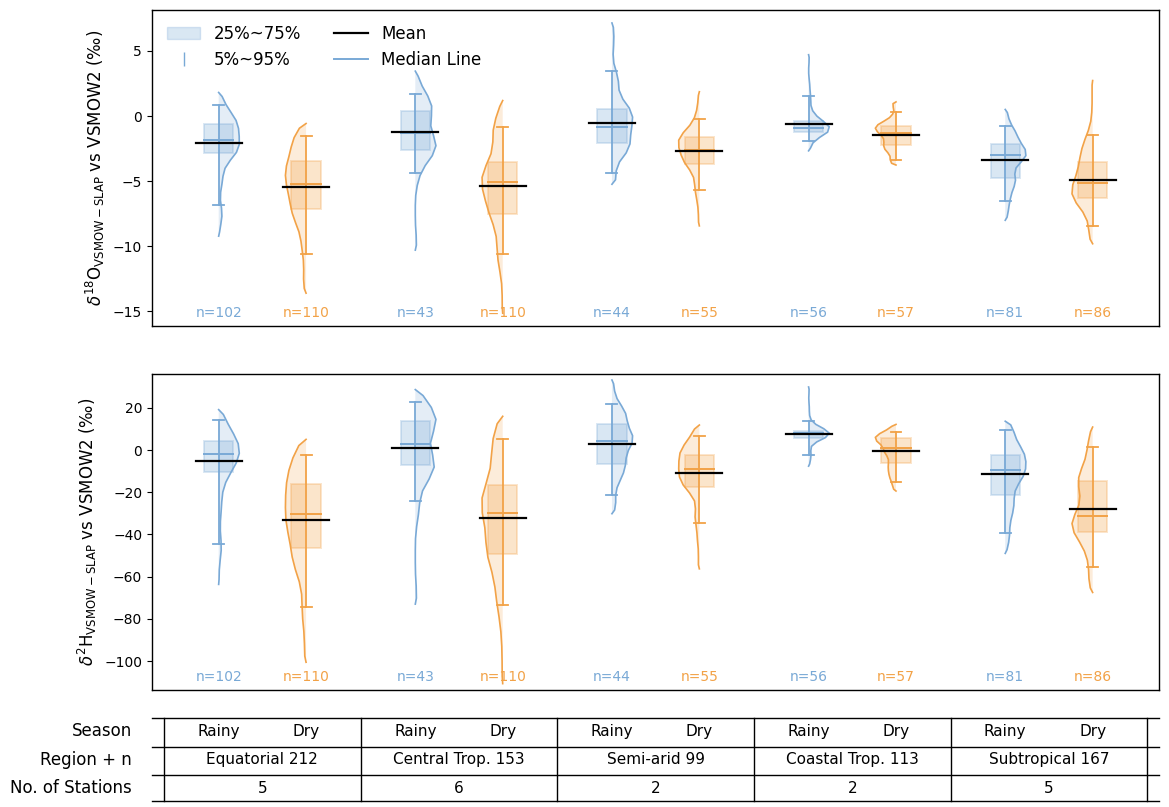

Saved: C:\Users\csilv\Desktop\IAEA\Artigo-SGB\Regional_Seasonal_Boxplots_Isotopes_5regions_sidehist.png


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib import transforms
from pathlib import Path

# =========================================================
# 1. INPUT
# =========================================================
file_path = "path/Water_Stable_Isotopes_Brazil_28Mar26.xlsx"
sheet_name = 0

# =========================================================
# 2. READ DATA
# =========================================================
df = pd.read_excel(file_path, sheet_name=sheet_name)

required_cols = [
    "Sample Date (monthly)",
    "Location",
    "δ²H (‰ vs VSMOW)",
    "δ¹⁸O (‰ vs VSMOW)"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["Sample Date (monthly)"] = pd.to_datetime(df["Sample Date (monthly)"], errors="coerce")
df["δ²H (‰ vs VSMOW)"] = pd.to_numeric(df["δ²H (‰ vs VSMOW)"], errors="coerce")
df["δ¹⁸O (‰ vs VSMOW)"] = pd.to_numeric(df["δ¹⁸O (‰ vs VSMOW)"], errors="coerce")
df = df.dropna(subset=required_cols).copy()

# =========================================================
# 3. REGION MAPPING
# =========================================================
station_region = {
    "Belém": "Equatorial",
    "Manaus": "Equatorial",
    "Santarém": "Equatorial",
    "Marabá": "Equatorial",
    "Porto Velho": "Equatorial",

    "Goiânia": "Central Trop.",
    "Palmas": "Central Trop.",
    "Cuiabá": "Central Trop.",
    "Barreiras": "Central Trop.",
    "Areado": "Central Trop.",
    "Petrópolis": "Central Trop.",

    "Juazeiro do Norte": "Semi-arid",
    "Teresina": "Semi-arid",

    "Salvador": "Coastal Trop.",
    "Recife": "Coastal Trop.",

    "Porto Alegre": "Subtropical",
    "Frederico Westphalen": "Subtropical",
    "Curitiba": "Subtropical",
    "Criciúma": "Subtropical",
    "Toledo": "Subtropical",
}

df["Region"] = df["Location"].map(station_region)
df = df.dropna(subset=["Region"]).copy()

region_order = [
    "Equatorial",
    "Central Trop.",
    "Semi-arid",
    "Coastal Trop.",
    "Subtropical"
]

# =========================================================
# 4. SEASON DEFINITION
# =========================================================
df["month"] = df["Sample Date (monthly)"].dt.month
df["Season"] = np.where(df["month"].isin([5, 6, 7, 8, 9, 10]), "Rainy", "Dry")
season_order = ["Rainy", "Dry"]

# =========================================================
# 5. STYLES
# =========================================================
season_colors = {
    "Rainy": "#79A9D6",
    "Dry":   "#F2A247"
}

# =========================================================
# 6. X POSITIONS
# =========================================================
within_gap = 0.72
region_gap = 0.45

x_positions = {}
region_centers = {}
region_boundaries = []

current_x = 1.0
for region in region_order:
    x_rainy = current_x
    x_dry = current_x + within_gap

    x_positions[(region, "Rainy")] = x_rainy
    x_positions[(region, "Dry")] = x_dry
    region_centers[region] = (x_rainy + x_dry) / 2

    left = x_rainy - 0.45
    right = x_dry + 0.45
    region_boundaries.append((left, right))

    current_x = x_dry + region_gap + 0.45

xmin_plot = region_boundaries[0][0] - 0.10
xmax_plot = region_boundaries[-1][1] + 0.10

# =========================================================
# 7. HELPERS
# =========================================================
def smooth_hist(counts, passes=2):
    """Light smoothing of histogram counts without scipy."""
    counts = counts.astype(float)
    kernel = np.array([1, 2, 1], dtype=float)
    kernel /= kernel.sum()
    for _ in range(passes):
        counts = np.convolve(counts, kernel, mode="same")
    return counts

def draw_side_histogram(ax, values, xpos, color, side="right",
                        bins=18, max_width=0.17, alpha=0.18, lw=1.1):
    """
    Draw a one-sided histogram silhouette beside the boxplot.
    side='right' or 'left'
    """
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return

    counts, edges = np.histogram(values, bins=bins)
    counts = smooth_hist(counts, passes=2)

    if counts.max() == 0:
        return

    widths = counts / counts.max() * max_width
    y_centers = 0.5 * (edges[:-1] + edges[1:])

    # Extend ends so the outline closes more naturally
    y_plot = np.r_[edges[0], y_centers, edges[-1]]
    w_plot = np.r_[0, widths, 0]

    if side == "right":
        x_outer = xpos + w_plot
        ax.fill_betweenx(y_plot, xpos, x_outer, facecolor=color, alpha=alpha, lw=0, zorder=1)
        ax.plot(x_outer, y_plot, color=color, lw=lw, zorder=2)
    else:
        x_outer = xpos - w_plot
        ax.fill_betweenx(y_plot, x_outer, xpos, facecolor=color, alpha=alpha, lw=0, zorder=1)
        ax.plot(x_outer, y_plot, color=color, lw=lw, zorder=2)

def draw_group(ax, values, xpos, color, hist_side="right",
               box_width=0.24, hist_width=0.17):
    values = np.asarray(values)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return

    # one-sided histogram silhouette
    draw_side_histogram(
        ax, values, xpos, color,
        side=hist_side,
        bins=18,
        max_width=hist_width,
        alpha=0.20,
        lw=1.2
    )

    # summary stats
    q25 = np.percentile(values, 25)
    q50 = np.percentile(values, 50)
    q75 = np.percentile(values, 75)
    p05 = np.percentile(values, 5)
    p95 = np.percentile(values, 95)
    mean = np.mean(values)

    # whisker
    ax.plot([xpos, xpos], [p05, p95], color=color, linewidth=1.3, zorder=4)
    ax.plot([xpos - 0.045, xpos + 0.045], [p05, p05], color=color, linewidth=1.3, zorder=4)
    ax.plot([xpos - 0.045, xpos + 0.045], [p95, p95], color=color, linewidth=1.3, zorder=4)

    # box
    rect = Rectangle(
        (xpos - box_width / 2, q25),
        box_width,
        q75 - q25,
        facecolor=color,
        edgecolor=color,
        alpha=0.28,
        linewidth=1.4,
        zorder=5
    )
    ax.add_patch(rect)

    # median line
    ax.plot(
        [xpos - box_width / 2, xpos + box_width / 2],
        [q50, q50],
        color=color,
        linewidth=1.4,
        zorder=6
    )

    # mean line
    ax.plot(
        [xpos - 0.19, xpos + 0.19],
        [mean, mean],
        color="black",
        linewidth=1.6,
        zorder=7
    )

def add_bottom_table(ax, grouped_counts, grouped_station_counts):
    y1 = -0.13
    y2 = -0.22
    y3 = -0.31

    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)

    ax.text(-0.02, y1, "Season", transform=ax.transAxes, ha="right", va="center", fontsize=12)
    ax.text(-0.02, y2, "Region + n", transform=ax.transAxes, ha="right", va="center", fontsize=12)
    ax.text(-0.02, y3, "No. of Stations", transform=ax.transAxes, ha="right", va="center", fontsize=12)

    for region in region_order:
        for season in season_order:
            x = x_positions[(region, season)]
            ax.text(x, y1, season, transform=trans, ha="center", va="center", fontsize=11)

    for region in region_order:
        x_center = region_centers[region]
        n_total = grouped_counts.get(region, 0)
        n_st = grouped_station_counts.get(region, 0)

        ax.text(x_center, y2, f"{region} {n_total}", transform=trans,
                ha="center", va="center", fontsize=11)
        ax.text(x_center, y3, f"{n_st}", transform=trans,
                ha="center", va="center", fontsize=11)

    for y in [y1 + 0.04, y2 + 0.04, y3 + 0.04, y3 - 0.04]:
        ax.plot([0, 1], [y, y], transform=ax.transAxes,
                color="black", lw=1.0, clip_on=False)

    for left, _ in region_boundaries:
        ax.plot([left, left], [y3 - 0.04, y1 + 0.04],
                transform=trans, color="black", lw=1.0, clip_on=False)

    rightmost = region_boundaries[-1][1]
    ax.plot([rightmost, rightmost], [y3 - 0.04, y1 + 0.04],
            transform=trans, color="black", lw=1.0, clip_on=False)

def make_panel(ax, data, value_col, ylabel):
    ymin, ymax = ax.get_ylim()
    y_n = ymin + 0.02 * (ymax - ymin)

    for region in region_order:
        for season in season_order:
            sub = data[
                (data["Region"] == region) &
                (data["Season"] == season)
            ][value_col].dropna()

            xpos = x_positions[(region, season)]

            # Put histogram outward from the pair center
            hist_side = "right" if season == "Rainy" else "left"

            draw_group(
                ax,
                sub.values,
                xpos,
                season_colors[season],
                hist_side=hist_side,
                box_width=0.24,
                hist_width=0.17
            )

            ax.text(
                xpos,
                y_n,
                f"n={len(sub)}",
                color=season_colors[season],
                ha="center",
                va="bottom",
                fontsize=10
            )

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

# =========================================================
# 8. COUNTS FOR TABLE
# =========================================================
grouped_counts = {
    region: len(df[df["Region"] == region])
    for region in region_order
}

grouped_station_counts = {
    region: df[df["Region"] == region]["Location"].nunique()
    for region in region_order
}

# =========================================================
# 9. CREATE FIGURE
# =========================================================
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(13, 10),
    sharex=True,
    gridspec_kw={"hspace": 0.15}
)

ax1.set_xlim(xmin_plot, xmax_plot)
ax2.set_xlim(xmin_plot, xmax_plot)

o18 = df["δ¹⁸O (‰ vs VSMOW)"].dropna()
h2 = df["δ²H (‰ vs VSMOW)"].dropna()

ax1.set_ylim(o18.min() - 1, o18.max() + 1)
ax2.set_ylim(h2.min() - 3, h2.max() + 3)

make_panel(ax1, df, "δ¹⁸O (‰ vs VSMOW)", r"$\delta^{18}$O$_{\mathrm{VSMOW-SLAP}}$ vs VSMOW2 (‰)")
make_panel(ax2, df, "δ²H (‰ vs VSMOW)",  r"$\delta^{2}$H$_{\mathrm{VSMOW-SLAP}}$ vs VSMOW2 (‰)")

add_bottom_table(ax2, grouped_counts, grouped_station_counts)

# =========================================================
# 10. LEGEND
# =========================================================
legend_handles = [
    Rectangle((0, 0), 1, 1,
              facecolor=season_colors["Rainy"],
              edgecolor=season_colors["Rainy"],
              alpha=0.28,
              label="25%~75%"),
    Line2D([0], [0],
           color=season_colors["Rainy"],
           lw=1.3,
           marker="|",
           markersize=10,
           linestyle="None",
           label="5%~95%"),
    # Line2D([0], [0],
    #        color=season_colors["Rainy"],
    #        lw=1.2,
    #        label="Side Histogram"),
    Line2D([0], [0],
           color="black",
           lw=1.6,
           label="Mean"),
    Line2D([0], [0],
           color=season_colors["Rainy"],
           lw=1.4,
           label="Median Line"),
]

ax1.legend(
    handles=legend_handles,
    loc="upper left",
    ncol=2,
    frameon=False,
    fontsize=12
)

# =========================================================
# 11. SAVE
# =========================================================
out_png = Path(file_path).with_name("Regional_Seasonal_Boxplots_Isotopes_5regions_sidehist.png")

plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")